In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import date, timedelta, datetime
from pathlib import Path
from scipy.signal import find_peaks
from scipy.stats import kendalltau
from itertools import combinations_with_replacement
from collections import Counter
from scipy.ndimage import gaussian_filter1d
import numpy as np
from sklearn.cluster import KMeans
import networkx as nx
from IPython.display import clear_output
import time
from scipy.stats import wasserstein_distance
INST = ["COP", "GOV", "INS", "JUD", "MIL", "OPP", "REB", "SEP", "SPY", "UAF", "AGR", "BUS", "CRM", "CVL", "DEV", "EDU", "ELI", "ENV", "HLH", "HRI", "LAB", "LEG", "MED", "REF", "MOD", "RAD"]

# example actor pair plot

In [3]:
#chn_usa = pd.read_csv("D:\gdelt_data\input_datasets\weekly_pw_filtered_features\CHN_USA_data.csv")
#
#for col in chn_usa.columns:
#    da = chn_usa[col]
#    plt.plot(da)
#    plt.title(col)
#    plt.show()

# Import Changepoints

## TIRE

In [111]:
tire_cps = np.array(np.load("model_codes/TIRE/experiment1_ws50.npy", allow_pickle=True).item()['both'])
tire_cps = np.nan_to_num(tire_cps, nan=0.0, copy=False)
tire_cps.shape

tire_fs = np.array(np.load("model_codes/TIRE/experiment1_ws50_fs.npy", allow_pickle=True).item()['both'])
tire_fs = np.nan_to_num(tire_fs, nan=0.0, copy=False)
tire_fs = np.pad(tire_fs, pad_width=((0,0), (49, 50)), mode='constant', constant_values=0)
tire_fs.shape

(224, 489)

In [112]:
mod_tire_cps = np.array(np.load("model_codes/TIRE/mod_experiment1_ws50.npy", allow_pickle=True).item()['both'])
mod_tire_fs = np.array(np.load("model_codes/TIRE/mod_experiment1_ws50_fs.npy", allow_pickle=True).item()['both'])
mod_tire_cps = np.nan_to_num(mod_tire_cps, nan=0.0, copy=False)
mod_tire_fs = np.nan_to_num(mod_tire_fs, nan=0.0, copy=False)
mod_tire_fs = np.pad(mod_tire_fs, pad_width=((0,0), (49, 50)), mode='constant', constant_values=0)
mod_tire_fs.shape

(224, 489)

## TSCP2

In [6]:
tscp2_cps = pd.read_csv("model_codes/TSCP2/src/experiment0.csv").to_numpy()
tscp2_cps = np.pad(tscp2_cps, pad_width=((0,0), (49, 50)), mode='constant', constant_values=0)
tscp2_cps.shape

(224, 489)

In [7]:
t_cps = np.empty(len(tscp2_cps), dtype=object)

for i in range(len(tscp2_cps)):
    t_cps[i] = find_peaks(tscp2_cps[i],height=1,prominence=1)[0]

t_zeros = np.zeros((t_cps.shape[0], 489))
for i in range(t_cps.shape[0]):
    t_zeros[i, t_cps[i]] = 1

In [8]:
tscp2_cps_mod = pd.read_csv("model_codes/TSCP2/src/experiment0_mod.csv").to_numpy()
tscp2_cps_mod = np.pad(tscp2_cps_mod, pad_width=((0,0), (49, 50)), mode='constant', constant_values=0)
tscp2_cps_mod.shape

(224, 489)

In [9]:
t_cps_mod = np.empty(len(tscp2_cps_mod), dtype=object)

for i in range(len(tscp2_cps_mod)):
    t_cps_mod[i] = find_peaks(tscp2_cps_mod[i],height=0.5,prominence=0.5)[0]

t_zeros_mod = np.zeros((t_cps_mod.shape[0], 489))
for i in range(t_cps_mod.shape[0]):
    t_zeros_mod[i, t_cps_mod[i]] = 1

In [10]:
t_zeros_mod.sum()

np.float64(700.0)

## SN-ts2vec

In [11]:
# raw scores
snts_fs = np.load("model_codes/SN-ts2vec/exp_fullscores.npy", allow_pickle=True)
snts_fs = np.pad(snts_fs, pad_width=((0,0), (50, 50)), mode='constant', constant_values=0)
snts_fs.shape

(224, 489)

In [12]:
#snts_cps = np.empty(len(snts_fs), dtype=object)

#for i in range(len(snts_fs)):
#    snts_cps[i] = find_peaks(snts_fs[i],height=0.5,prominence=0.5)[0]

#s_zeros = np.zeros((snts_cps.shape[0], 489))
#for i in range(snts_cps.shape[0]):
#    s_zeros[i, snts_cps[i]] = 1

In [13]:
#snts_cps = np.load("model_codes/SN-ts2vec/pred_cp_ad.npy", allow_pickle=True)
snts_cps = np.load("model_codes/SN-ts2vec/pred_cp_window50.npy", allow_pickle=True)
s_zeros = np.zeros((snts_cps.shape[0], 489))
s_zeros.shape
for i in range(snts_cps.shape[0]):
    s_zeros[i, snts_cps[i]] = 1

In [14]:
snts_fs_mod = np.load("model_codes/SN-ts2vec/exp_fullscores_modified.npy", allow_pickle=True)
snts_fs_mod = np.pad(snts_fs_mod, pad_width=((0,0), (50, 50)), mode='constant', constant_values=0)
snts_fs_mod.shape

(224, 489)

In [15]:
snts_cps_mod = np.empty(len(snts_fs_mod), dtype=object)

for i in range(len(snts_fs_mod)):
    snts_cps_mod[i] = find_peaks(snts_fs_mod[i],height=0.5,prominence=0.5)[0]

s_zeros_mod = np.zeros((snts_cps_mod.shape[0], 489))
for i in range(snts_cps_mod.shape[0]):
    s_zeros_mod[i, snts_cps_mod[i]] = 1

In [16]:
#snts_cps_mod = np.load("model_codes/SN-ts2vec/cps_modified.npy", allow_pickle=True)
#s_zeros_mod = np.zeros((snts_cps_mod.shape[0], 489))
#s_zeros_mod.shape
#for i in range(snts_cps_mod.shape[0]):
#    s_zeros_mod[i, snts_cps_mod[i]] = 1

## ruptures

In [17]:
rpt_fs = np.load("gdelt/ruptures/ruptures_window_fs.npy")
rpt_fs = np.nan_to_num(rpt_fs, nan=0.0)

In [18]:
rpt_cps = np.load("gdelt/ruptures/ruptures_window_cp.npy")
#rpt_cps = pd.read_csv("gdelt/ruptures_windows_cp.csv").to_numpy()
rpt_cps = rpt_cps[:, :-1]
len(rpt_cps[0])

489

In [19]:
rpt_rel_cps = np.load("gdelt/ruptures/ruptures_exp_rel.npy")
rpt_rel_cps = rpt_rel_cps[:, :-1]
len(rpt_rel_cps[0])

489

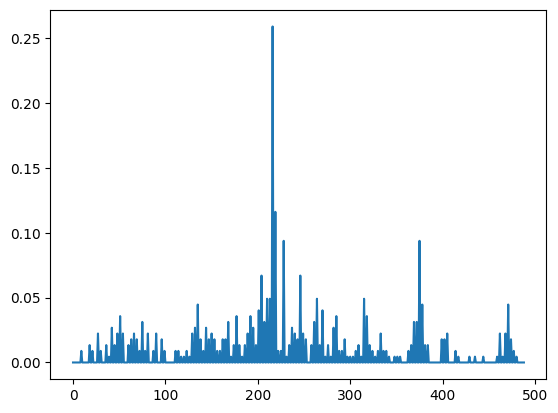

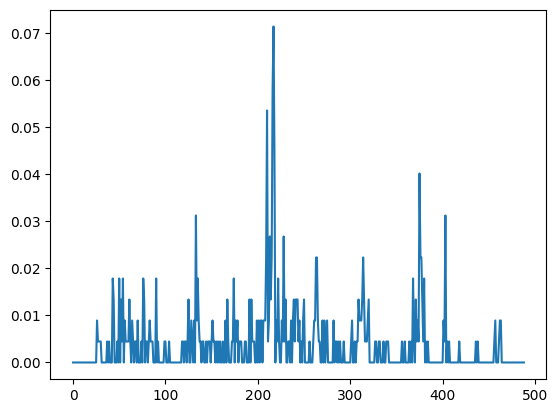

In [20]:
plt.plot(np.mean(rpt_rel_cps, axis=0))
plt.show()

plt.plot(np.mean(rpt_cps, axis=0))
plt.show()

In [21]:
dir_path = "..\data\input_datasets\weekly_pw_filtered_features"
file_names = [f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))]

start_date = datetime(2016, 1, 4)
date_list = [start_date + timedelta(weeks=i) for i in range(489)]

In [22]:
for i in range(489):
    # Check which files (rows) have a 1 in column 'i'
    # rpt_cps[:, i] selects the entire column for feature i
    matching_file_indices = np.where(rpt_rel_cps[:, i] == 1)[0]
    if len(matching_file_indices) > 0:
        print(f"--- Changepoint {i} (week {date_list[i]}) was detected for entity pairs: ---")
        for file_idx in matching_file_indices:
            print(file_names[file_idx])
# BUS: business, LEG: legislative, GOV: government, COP: police, JUD: judiciary, MED: media

--- Changepoint 9 (week 2016-03-07 00:00:00) was detected for entity pairs: ---
AUS_GOV_data.csv
GOV_AUS_data.csv
--- Changepoint 18 (week 2016-05-09 00:00:00) was detected for entity pairs: ---
CRM_USA_data.csv
CVL_BUS_data.csv
USA_USALEG_data.csv
--- Changepoint 21 (week 2016-05-30 00:00:00) was detected for entity pairs: ---
BUS_AUS_data.csv
EDU_GOV_data.csv
--- Changepoint 27 (week 2016-07-11 00:00:00) was detected for entity pairs: ---
CVL_EDU_data.csv
EDU_CVL_data.csv
RUS_RUSGOV_data.csv
USA_EDU_data.csv
USA_ISR_data.csv
--- Changepoint 30 (week 2016-08-01 00:00:00) was detected for entity pairs: ---
GOV_EDU_data.csv
USA_OPP_data.csv
--- Changepoint 36 (week 2016-09-12 00:00:00) was detected for entity pairs: ---
EDU_GOV_data.csv
LEG_USA_data.csv
USACVL_USA_data.csv
--- Changepoint 39 (week 2016-10-03 00:00:00) was detected for entity pairs: ---
BUS_GOV_data.csv
--- Changepoint 42 (week 2016-10-24 00:00:00) was detected for entity pairs: ---
COP_EDU_data.csv
DEU_USA_data.csv
GOV_

# Evaluation metrics

## Matrix correlation of flattened arrays

In [23]:
def matrix_correlation(A, B):
    # Flatten both matrices to 1D vectors
    return np.corrcoef(A.ravel(), B.ravel())[0, 1]

print(matrix_correlation(tire_cps, tscp2_cps)) # very low
print(matrix_correlation(tire_cps, rpt_cps))
print(matrix_correlation(rpt_cps, tscp2_cps))

print(matrix_correlation(s_zeros, tscp2_cps)) # very low
print(matrix_correlation(tire_cps, s_zeros))
print(matrix_correlation(rpt_cps, s_zeros))

0.052483800917056275
0.009318514832353925
0.05071001604773835
0.07481787709855746
0.008743362129090633
0.09469429378651747


## Correlation on location of most likely change points

In [24]:
np.argmax(tscp2_cps, axis=1).ravel()

print(matrix_correlation(np.argmax(tire_cps, axis=1).ravel(), np.argmax(tscp2_cps, axis=1).ravel()))
print(matrix_correlation(np.argmax(rpt_cps, axis=1).ravel(), np.argmax(tscp2_cps, axis=1).ravel()))
print(matrix_correlation(np.argmax(tire_cps, axis=1).ravel(), np.argmax(rpt_cps, axis=1).ravel()))

print(matrix_correlation(np.argmax(s_zeros, axis=1).ravel(), np.argmax(tscp2_cps, axis=1).ravel()))
print(matrix_correlation(np.argmax(rpt_cps, axis=1).ravel(), np.argmax(s_zeros, axis=1).ravel()))
print(matrix_correlation(np.argmax(tire_cps, axis=1).ravel(), np.argmax(s_zeros, axis=1).ravel()))

-0.03188651598824241
-0.05308316093007416
0.09270719201858262
0.16649330163939202
0.18895963663708215
-0.04005905185277487


## Distances between the changepoints

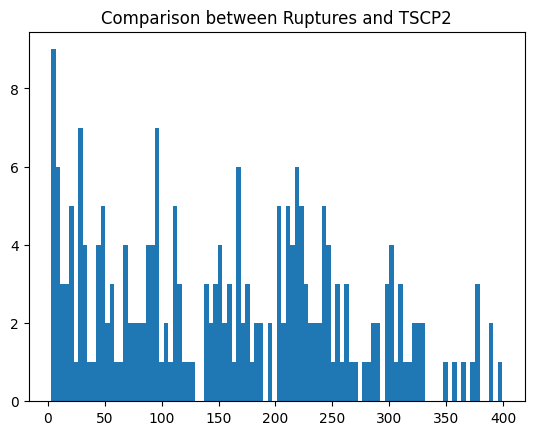

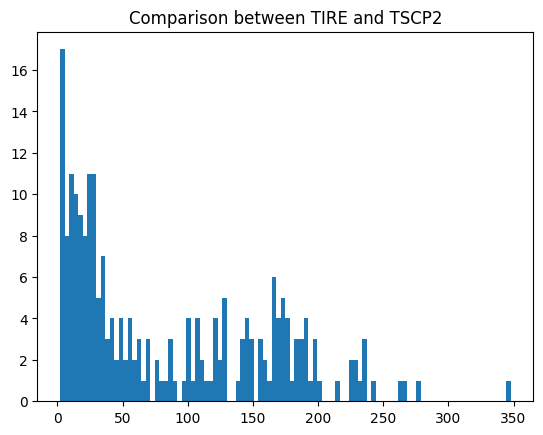

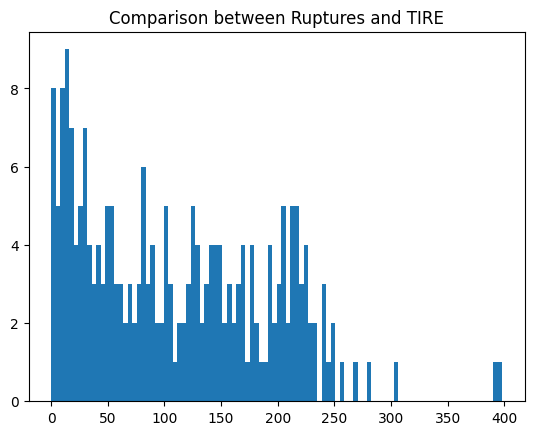

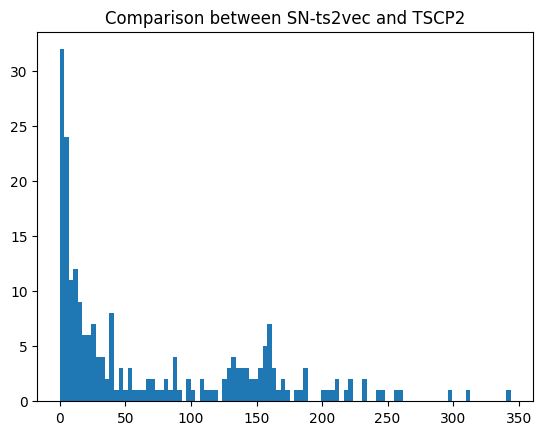

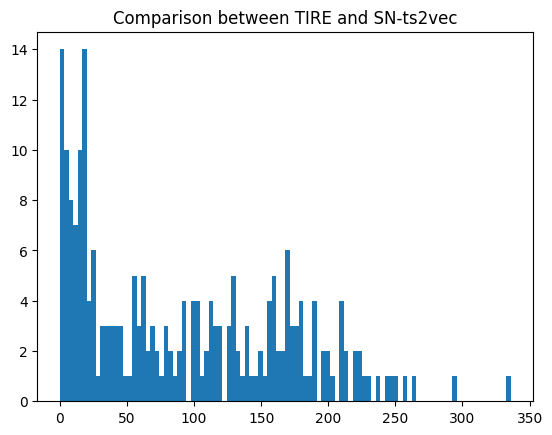

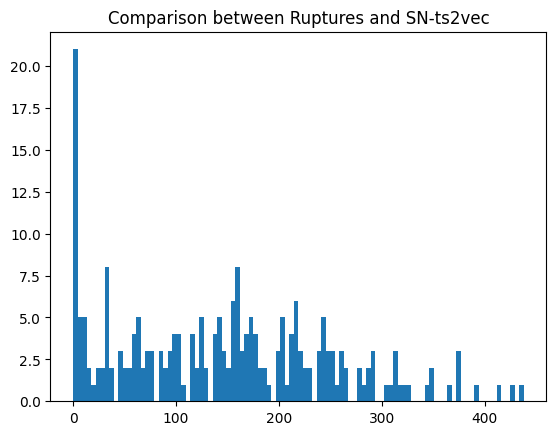

In [25]:
plt.hist(np.abs(np.argmax(rpt_cps, axis=1).ravel() - np.argmax(tscp2_cps, axis=1).ravel()), bins=100)
plt.title("Comparison between Ruptures and TSCP2")
plt.show()

plt.hist(np.abs(np.argmax(tire_cps, axis=1).ravel() - np.argmax(tscp2_cps, axis=1).ravel()), bins=100)
plt.title("Comparison between TIRE and TSCP2")
plt.show()

plt.hist(np.abs(np.argmax(rpt_cps, axis=1).ravel() - np.argmax(tire_cps, axis=1).ravel()), bins=100)
plt.title("Comparison between Ruptures and TIRE")
plt.show()

plt.hist(np.abs(np.argmax(s_zeros, axis=1).ravel() - np.argmax(tscp2_cps, axis=1).ravel()), bins=100)
plt.title("Comparison between SN-ts2vec and TSCP2")
plt.show()

plt.hist(np.abs(np.argmax(tire_cps, axis=1).ravel() - np.argmax(s_zeros, axis=1).ravel()), bins=100)
plt.title("Comparison between TIRE and SN-ts2vec")
plt.show()

plt.hist(np.abs(np.argmax(rpt_cps, axis=1).ravel() - np.argmax(s_zeros, axis=1).ravel()), bins=100)
plt.title("Comparison between Ruptures and SN-ts2vec")
plt.show()

## Effects of the changepoints on the different variables

In [27]:
df = pd.read_csv("D:/gdelt_data/input_datasets/weekly_pw_filtered_features/AFR_GOV_data.csv")
ws_pp = df.copy()
cols = ["mentions", "events", "avg_sentenceid", "avg_a1co", "avg_a2co", "avg_actco", "avg_raw_text", "avg_root_event", "avg_len", "avg_goldstein", "avg_tone", "avg_confidence", "avg_lat1", "avg_lon1", "avg_lat2", "avg_lon2", "avg_lata", "avg_lona", 
        "total_num_mentions", "total_num_sources", "total_num_articles"]
X = ws_pp[cols].to_numpy()
X = (X - X.mean(axis=0)) / X.std(axis=0)

## Changes to the variables

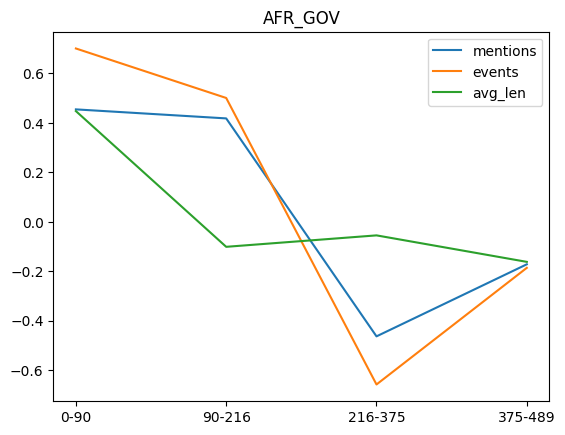

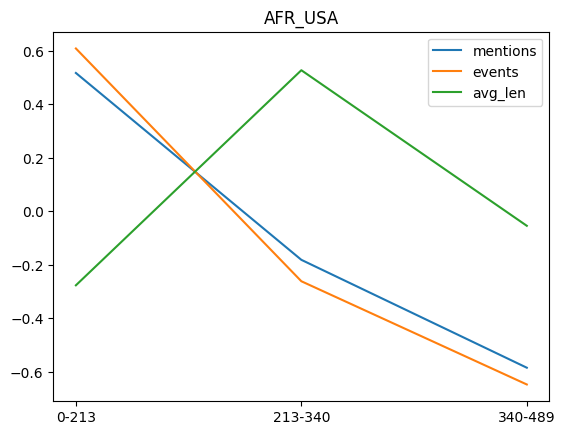

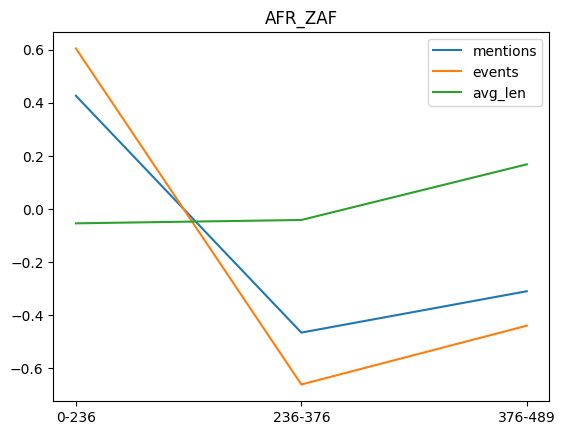

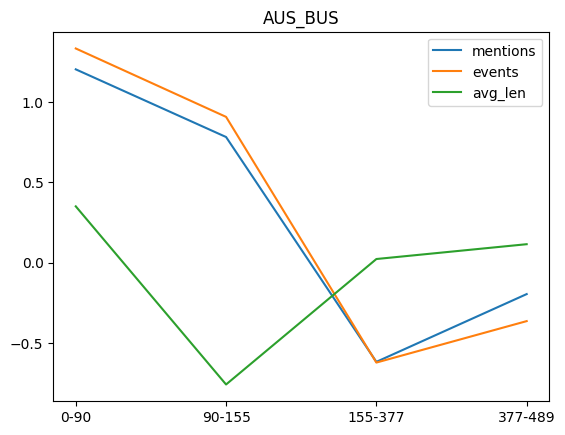

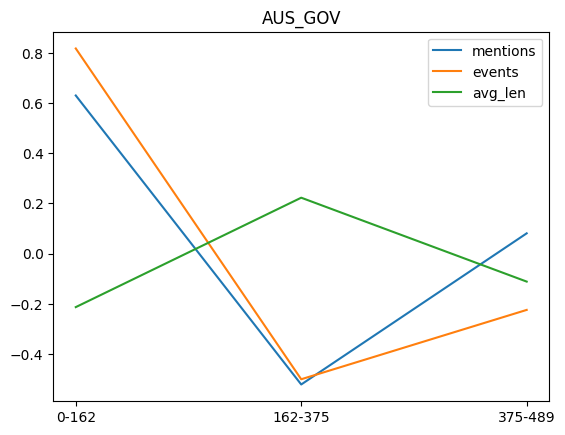

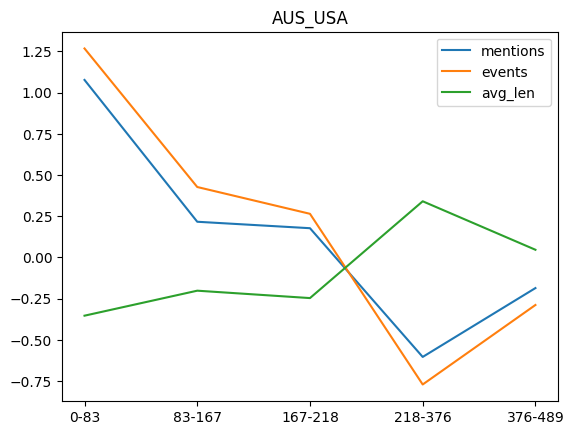

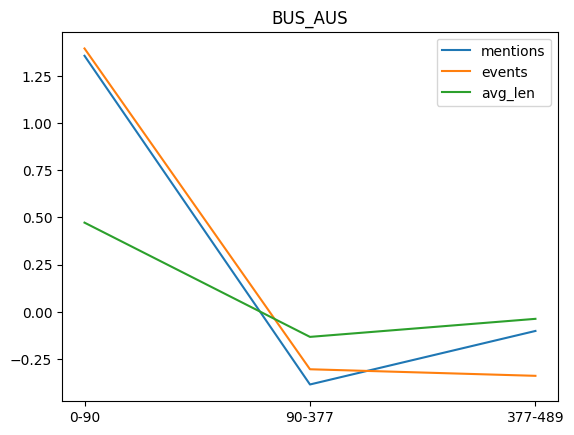

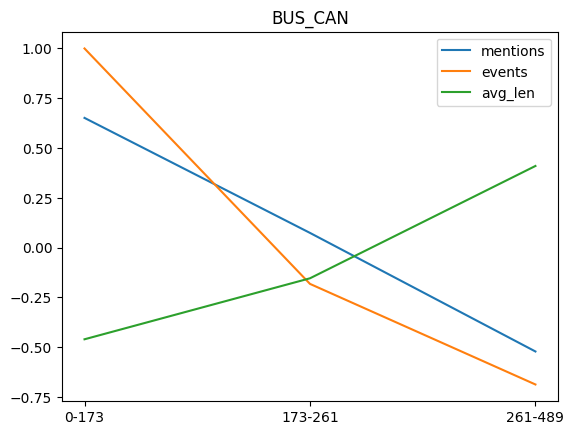

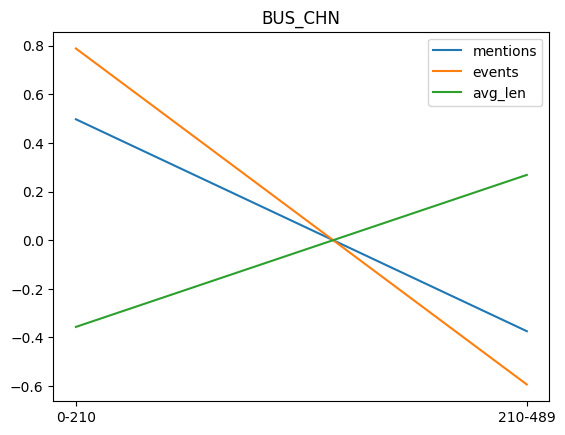

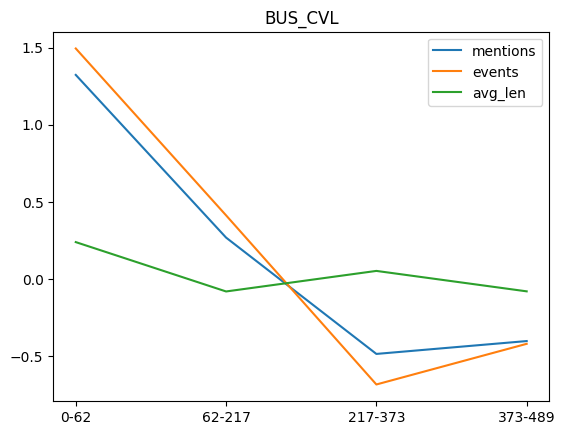

In [28]:
data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
cols = ["mentions", "events", "avg_sentenceid", "avg_a1co", "avg_a2co", "avg_actco", "avg_raw_text", "avg_root_event", "avg_len", "avg_goldstein", "avg_tone", "avg_confidence", "avg_lat1", "avg_lon1", "avg_lat2", "avg_lon2", "avg_lata", "avg_lona", 
            "total_num_mentions", "total_num_sources", "total_num_articles"]

for i, csv_file in enumerate(data_dir.glob("*.csv")):
    if i == 10:
        break
    df = pd.read_csv(csv_file)
    ws_pp = df.copy()
    X = ws_pp[cols].to_numpy()
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    rows = []
    index = []

    prev_cp = 0

    for cp in np.where(rpt_cps[i] == 1)[0]:
        subX = X[prev_cp:cp]
        row = np.mean(subX, axis=0)
        rows.append(row)
        index.append(f"{prev_cp}-{cp}")      # or prev_cp, or f"{prev_cp}-{cp}"
        prev_cp = cp

        if cp == np.where(rpt_cps[i] == 1)[0][-1]:
            subX = X[prev_cp:]
            row = np.mean(subX, axis=0)
            rows.append(row)
            index.append(f"{prev_cp}-489")

    df = pd.DataFrame(
        rows,
        index=index,
        columns=cols
    )

    for col in df.columns:
        if col in ["mentions", "events", "avg_len"]:
            plt.plot(df[col], label=col)
    plt.title(f"{csv_file.stem[:-5]}")
    plt.legend()
    plt.show()

## Absolute values

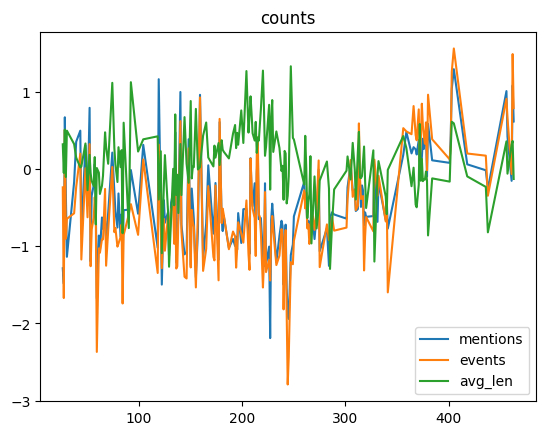

In [29]:
data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
cols = ["mentions", "events", "avg_sentenceid", "avg_a1co", "avg_a2co", "avg_actco", "avg_raw_text", "avg_root_event", "avg_len", "avg_goldstein", "avg_tone", "avg_confidence", "avg_lat1", "avg_lon1", "avg_lat2", "avg_lon2", "avg_lata", "avg_lona", 
            "total_num_mentions", "total_num_sources", "total_num_articles"]

all_dfs = []

for i, csv_file in enumerate(data_dir.glob("*.csv")):
    #if i == 10:
    #    break
    df = pd.read_csv(csv_file)
    ws_pp = df.copy()
    X = ws_pp[cols].to_numpy()
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    rows = []
    index = []

    prev_cp = 0
    prev_row = None

    cps = np.where(rpt_cps[i] == 1)[0]
    if len(cps) < 2:
        continue

    for cp in np.where(rpt_cps[i] == 1)[0]:
        subX = X[prev_cp:cp]
        row = np.mean(subX, axis=0)
        if prev_row is not None:
            rows.append(row - prev_row)
            index.append(int(prev_cp))      # or prev_cp, or f"{prev_cp}-{cp}"

        prev_cp = cp
        prev_row = row

        if cp == np.where(rpt_cps[i] == 1)[0][-1]:
            subX = X[prev_cp:]
            row = np.mean(subX, axis=0)
            rows.append(row - prev_row)
            index.append(int(cp))

    df = pd.DataFrame(
        rows,
        index=index,
        columns=cols
    )

    all_dfs.append(df)

total = pd.concat(all_dfs).sort_index()
total_means = total.groupby(by=total.index).mean()

for col in total_means.columns:
    if col in ["mentions", "events", "avg_len"]:
        plt.plot(total_means[col], label=col)
plt.title(f"counts")
plt.legend()
plt.show()

In [30]:
total.groupby(total.index).count().sort_values(by=total.columns[0], ascending=False)

,mentions,events,avg_sentenceid,avg_a1co,avg_a2co,avg_actco,avg_raw_text,avg_root_event,avg_len,avg_goldstein,...,avg_confidence,avg_lat1,avg_lon1,avg_lat2,avg_lon2,avg_lata,avg_lona,total_num_mentions,total_num_sources,total_num_articles
217,12,12,12,12,12,12,12,12,12,12,...,12,12,12,12,12,12,12,12,12,12
216,10,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,10
375,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
210,8,8,8,8,8,8,8,8,8,8,...,8,8,8,8,8,8,8,8,8,8
403,6,6,6,6,6,6,6,6,6,6,...,6,6,6,6,6,6,6,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
456,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
438,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
461,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [31]:
tire_cps
rpt_cps
tscp2_cps

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(224, 489))

## threshold / restructuring data for tscp2

In [32]:
s_zeros[6]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

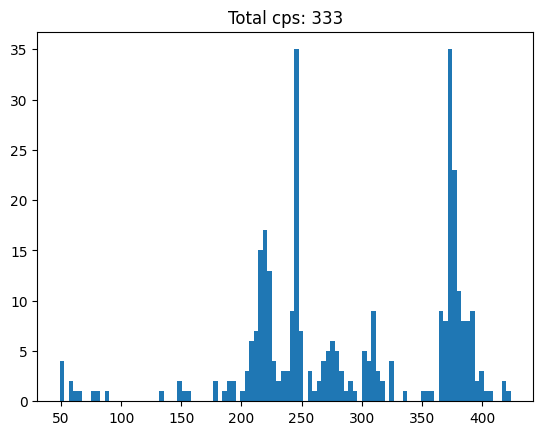

In [33]:
plt.hist(np.concatenate(t_cps), bins=100)
plt.title(f"Total cps: {sum(len(p) for p in t_cps)}")
plt.show()

## Aggregation of changepoint scores across models

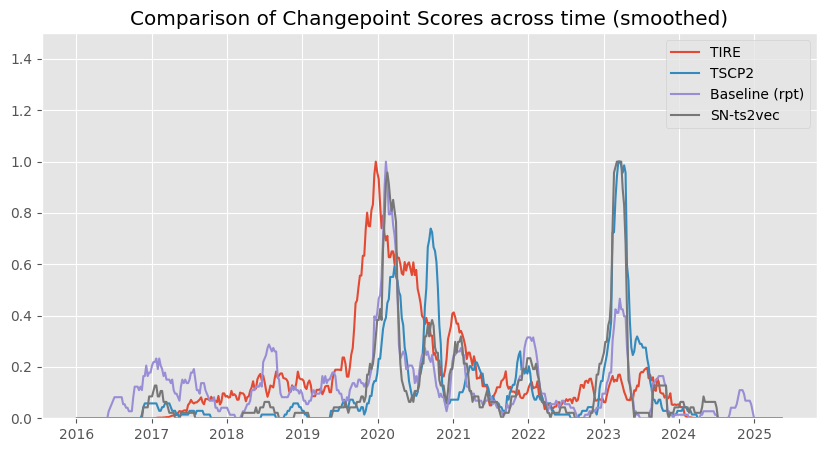

In [34]:
kernel = np.ones(10) / 10

tire = np.convolve(np.mean(tire_cps, axis=0), kernel, mode="same")
mod_tire = np.convolve(np.mean(mod_tire_cps, axis=0), kernel, mode="same")
rpt = np.convolve(np.mean(rpt_cps, axis=0), kernel, mode="same")
tscp2 = np.convolve(np.mean(t_zeros, axis=0), kernel, mode="same")
snts = np.convolve(np.mean(s_zeros, axis=0), kernel, mode="same")

norm_tire = tire / np.max(tire)
#norm_mod_tire = mod_tire / np.max(mod_tire)
norm_rpt = rpt / np.max(rpt)
norm_tscp2 = tscp2 / np.max(tscp2)
norm_snts = snts / np.max(snts)

dates = pd.date_range(
    start="2016-01-04",
    periods=len(norm_tire),
    freq="7D"
)

plt.figure(figsize=(10, 5))
#plt.style.use("default")
plt.style.use('ggplot')
plt.plot(dates, norm_tire, label="TIRE")
plt.plot(dates, norm_tscp2, label="TSCP2")
#plt.plot(dates, norm_mod_tire, label="Mod-TIRE")
plt.plot(dates, norm_rpt, label="Baseline (rpt)")
plt.plot(dates, norm_snts, label="SN-ts2vec")

plt.ylim(0, 1.5)
plt.title("Comparison of Changepoint Scores across time (smoothed)")
plt.legend()
plt.show()

In [35]:
print(find_peaks(norm_tire, height=0.1, distance=50))
print(find_peaks(norm_rpt, height=0.1, distance=50))
print(find_peaks(norm_tscp2, height=0.1, distance=50))
print(find_peaks(norm_snts, height=0.1, distance=50))

(array([138, 207, 261, 319, 395]), {'peak_heights': array([0.18266585, 1.        , 0.41245587, 0.14425564, 0.1969351 ])})
(array([ 57, 133, 214, 266, 316, 376, 460]), {'peak_heights': array([0.23287671, 0.28767123, 1.        , 0.2739726 , 0.31506849,
       0.46575342, 0.10958904])})
(array([245, 307, 375]), {'peak_heights': array([0.73913043, 0.26086957, 1.        ])})
(array([ 54, 215, 266, 318, 374]), {'peak_heights': array([0.12765957, 0.95744681, 0.31914894, 0.21276596, 1.        ])})


In [36]:
rpt_peaks = find_peaks(norm_rpt, height=0.1, distance=50)
tire_peaks = find_peaks(norm_tire, height=0.1, distance=50)
tscp2_peaks = find_peaks(norm_tscp2, height=0.1, distance=50)
snts_peaks = find_peaks(norm_snts, height=0.1, distance=50)

dates[tire_peaks[0]]

DatetimeIndex(['2018-08-27', '2019-12-23', '2021-01-04', '2022-02-14',
               '2023-07-31'],
              dtype='datetime64[us]', freq=None)

In [37]:
np.nonzero(rpt_cps[0])[0]

array([ 90, 216, 375])

In [38]:
all_actor_list = []
for file_name in file_names:
    a1 = file_name.split('_')[0]
    a2 = file_name.split('_')[1]
    all_actor_list.append(a1)
    all_actor_list.append(a2)
all_actor_list = Counter(all_actor_list)
print(all_actor_list)

Counter({'USA': 80, 'GOV': 59, 'BUS': 23, 'GBR': 23, 'CVL': 22, 'COP': 21, 'EDU': 16, 'MED': 15, 'CHN': 13, 'JUD': 11, 'CAN': 9, 'MIL': 9, 'RUS': 9, 'AUS': 8, 'HLH': 7, 'ISR': 7, 'USAGOV': 7, 'AFR': 6, 'LAB': 6, 'OPP': 6, 'FRA': 6, 'LEG': 6, 'CRM': 5, 'MNCUSA': 4, 'DEU': 4, 'USAEDU': 4, 'IRL': 4, 'IRN': 4, 'NGA': 4, 'PTY': 3, 'USAMED': 3, 'ZAF': 2, 'CHNGOV': 2, 'ELI': 2, 'EUR': 2, 'GBRGOV': 2, 'IND': 2, 'PAK': 2, 'PSE': 2, 'ITA': 2, 'MEX': 2, 'NGAGOV': 2, 'REL': 2, 'RUSGOV': 2, 'USABUS': 2, 'USACOP': 2, 'USACVL': 2, 'USAELI': 2, 'USAJUD': 2, 'USALEG': 2, 'CANGOV': 1, 'PHL': 1, 'ISRGOV': 1, 'JPN': 1, 'UAF': 1, 'USAHLH': 1})


Peak: 57
Counter({'USA': 8, 'GOV': 7, 'CVL': 2, 'HLH': 2, 'JUD': 2, 'USAGOV': 2, 'BUS': 1, 'CRM': 1, 'EDU': 1, 'ELI': 1, 'USAMED': 1, 'LEG': 1, 'RUS': 1, 'RUSGOV': 1, 'LAB': 1, 'MEX': 1, 'UAF': 1, 'USAEDU': 1, 'USAHLH': 1})
{'USAMED': 0.3333333333333333, 'HLH': 0.2857142857142857, 'USAGOV': 0.2857142857142857, 'USAEDU': 0.25, 'CRM': 0.2, 'JUD': 0.18181818181818182, 'LEG': 0.16666666666666666, 'LAB': 0.16666666666666666, 'GOV': 0.11864406779661017, 'RUS': 0.1111111111111111, 'USA': 0.1, 'CVL': 0.09090909090909091, 'EDU': 0.0625, 'BUS': 0.043478260869565216}
Peak: 133
Counter({'USA': 9, 'BUS': 4, 'NGA': 4, 'MED': 3, 'GOV': 3, 'EDU': 2, 'NGAGOV': 2, 'MNCUSA': 1, 'CANGOV': 1, 'CAN': 1, 'CHN': 1, 'CHNGOV': 1, 'EUR': 1, 'GBR': 1, 'COP': 1, 'HLH': 1, 'ITA': 1, 'REL': 1, 'USAEDU': 1, 'USAELI': 1, 'CVL': 1, 'IRN': 1, 'MIL': 1, 'PTY': 1})
{'NGA': 1.0, 'PTY': 0.3333333333333333, 'MNCUSA': 0.25, 'USAEDU': 0.25, 'IRN': 0.25, 'MED': 0.2, 'BUS': 0.17391304347826086, 'HLH': 0.14285714285714285, 'EDU':

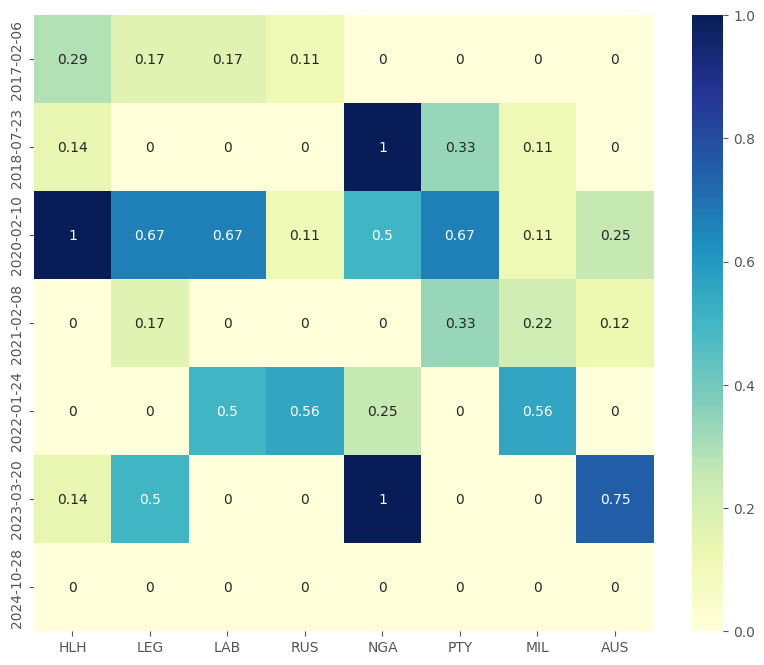

In [39]:
# investigate names of files corresponding to the peaks with tolerance of 5
for peak in rpt_peaks[0]:
    # find files corresponding to the peak with tolerance of 5
    actor_list = []
    for i, rpt_cp in enumerate(rpt_cps):
        cps = np.nonzero(rpt_cp)[0]
        for cp in cps:
            if abs(cp - peak) <= 5:
                #print(f"Series: {i}, Peak: {peak}, Matching rpt_cp: {cp}, file_name: {file_names[i]}")
                file_name = file_names[i]
                a1 = file_name.split('_')[0]
                a2 = file_name.split('_')[1]
                #print(f"a1: {a1}, a2: {a2}")
                actor_list.append(a1)
                actor_list.append(a2)
    print(f"Peak: {peak}")
    print(Counter(actor_list))
    actor_list = Counter(actor_list)
    result = {key: actor_list[key] / all_actor_list[key] for key in actor_list}
    # sort by values and keep only if the value in all_actor_list is greater than 2
    result = {key: value for key, value in result.items() if all_actor_list[key] > 2}
    result = dict(sorted(result.items(), key=lambda item: item[1], reverse=True))
    print(result)

# create heatmap of the results 
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = []
for peak in rpt_peaks[0]:
    actor_list = []
    for i, rpt_cp in enumerate(rpt_cps):
        cps = np.nonzero(rpt_cp)[0]
        for cp in cps:
            if abs(cp - peak) <= 5:
                file_name = file_names[i]
                a1 = file_name.split('_')[0]
                a2 = file_name.split('_')[1]
                actor_list.append(a1)
                actor_list.append(a2)
    actor_list = Counter(actor_list)
    result = {key: actor_list[key] / all_actor_list[key] for key in actor_list}
    result = {key: value for key, value in result.items() if all_actor_list[key] > 2}
    result = dict(sorted(result.items(), key=lambda item: item[1], reverse=True))
    heatmap_data.append(result)


# convert heatmap_data to a DataFrame
import pandas as pd
heatmap_df = pd.DataFrame(heatmap_data).fillna(0)
heatmap_df = heatmap_df.loc[:, (heatmap_df > 0.5).any(axis=0)]
y_labels = dates[rpt_peaks[0]]
# only dates (remove time part if present)
y_labels = [pd.to_datetime(date).date() for date in y_labels]


plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", yticklabels=y_labels)
plt.show()

In [40]:
heatmap_df
# exclude columns without a value greater than 0.5
heatmap_df = heatmap_df.loc[:, (heatmap_df > 0.5).any(axis=0)]
heatmap_df

,HLH,LEG,LAB,RUS,NGA,PTY,MIL,AUS
0,0.285714,0.166667,0.166667,0.111111,0.00,0.000000,0.000000,0.000
1,0.142857,0.000000,0.000000,0.000000,1.00,0.333333,0.111111,0.000
2,1.000000,0.666667,0.666667,0.111111,0.50,0.666667,0.111111,0.250
3,0.000000,0.166667,0.000000,0.000000,0.00,0.333333,0.222222,0.125
4,0.000000,0.000000,0.500000,0.555556,0.25,0.000000,0.555556,0.000
5,0.142857,0.500000,0.000000,0.000000,1.00,0.000000,0.000000,0.750
6,0.000000,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000


## threshold for tscp2

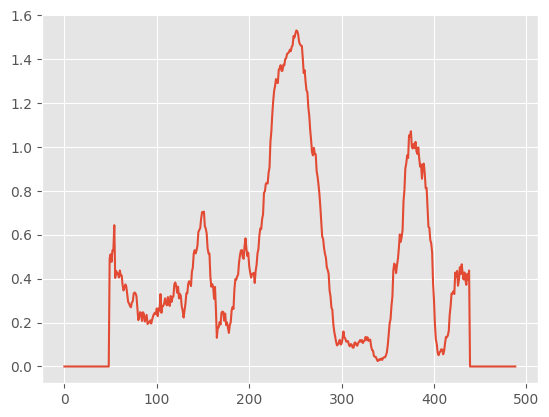

In [41]:
plt.plot(tscp2_cps[8])

## Data quality

In [42]:
file_names = [f.name for f in data_dir.iterdir() if f.is_file()]

In [136]:
X.mean(axis=0)

array([ 8.27525562e+02,  4.73235174e+02,  5.84949290e+00,  1.50583707e+03,
        1.44112504e+03,  1.51658878e+03,  1.14367033e-01,  7.75079393e-01,
        3.66790499e+03, -9.05196246e-02, -2.49018050e+00,  2.81396412e+01,
       -2.38890530e+01,  2.53689590e+01, -2.37600092e+01,  2.54390291e+01,
       -2.31790476e+01,  2.52605581e+01,  3.25069836e+04,  9.81914110e+03,
        3.18808937e+04])

In [43]:
def multivariate_snr(X):
    mu = X.mean(axis=0)
    cov = np.cov(X, rowvar=False)

    signal = np.dot(mu, mu)
    noise = np.trace(cov)

    return signal / noise

In [44]:
data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
cols = ["mentions", "events", "avg_sentenceid", "avg_a1co", "avg_a2co", "avg_actco", "avg_raw_text", "avg_root_event", "avg_len", "avg_goldstein", "avg_tone", "avg_confidence", "avg_lat1", "avg_lon1", "avg_lat2", "avg_lon2", "avg_lata", "avg_lona", 
            "total_num_mentions", "total_num_sources", "total_num_articles"]

ms = []
mean_mentions = []
min_mentions = []
actors = []
for i, csv_file in enumerate(data_dir.glob("*.csv")):
    df = pd.read_csv(csv_file)
    ws_pp = df.copy()
    X = ws_pp[cols].to_numpy()
    #X = (X - X.mean(axis=0)) / X.std(axis=0)
    ms.append(multivariate_snr(X))
    mean_mentions.append(np.mean(ws_pp["mentions"]))
    min_mentions.append(np.min(ws_pp["mentions"]))
    actors.append((ws_pp["a1c"].iloc[0], ws_pp["a2c"].iloc[0]))

# colors according to type: two countries, two institutions, one country and one institution, or other
colors = []
for a1, a2 in actors:
    if a1 in INST and a2 in INST:
        colors.append("green")  # two institutions
    elif a1 not in INST and a2 not in INST:
        colors.append("red")    # two countries
    elif (a1 in INST and a2 not in INST) or (a1 not in INST and a2 in INST):
        colors.append("blue")   # one country and one institution
    else:
        colors.append("gray")   # other

In [45]:
print(np.argmax(ms), file_names[np.argmax(ms)])
print(np.argmin(ms), file_names[np.argmin(ms)])

170 USA_BUS_data.csv
7 BUS_CAN_data.csv


In [46]:
# correlation between SNR and mean mentions and min mentions
np.corrcoef(ms, mean_mentions)[0, 1], np.corrcoef(ms, min_mentions)[0, 1]


(np.float64(0.4789347728466782), np.float64(0.5109152123073998))

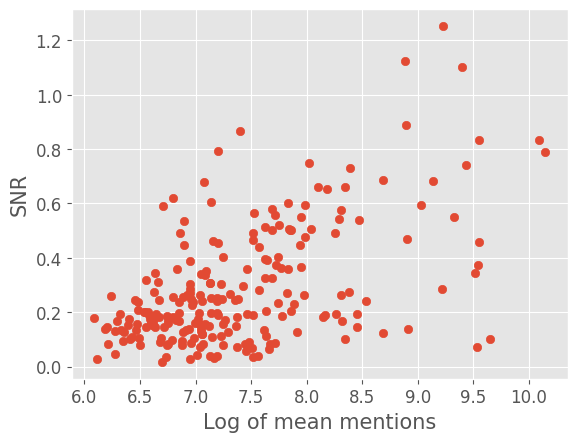

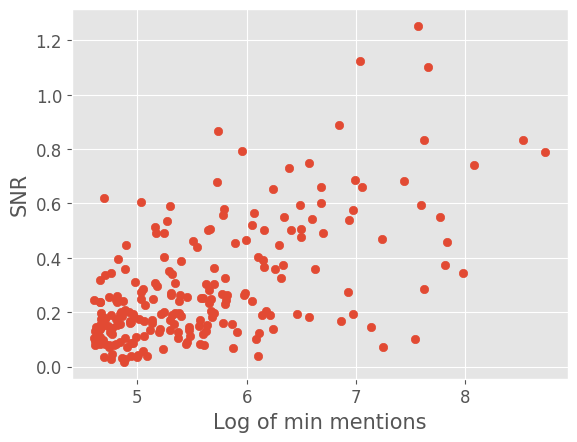

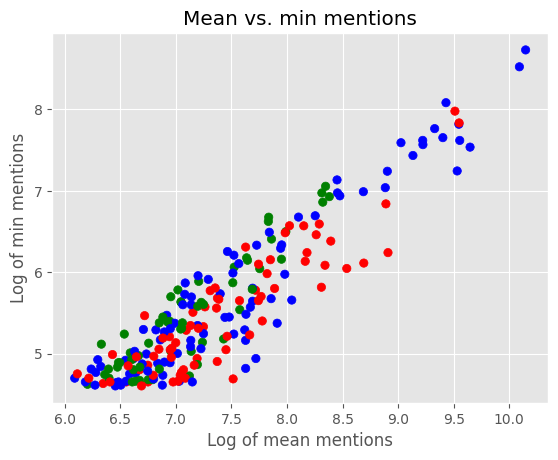

In [134]:
plt.scatter(np.log(mean_mentions), ms)
#plt.title("SNR vs. mean mentions")
plt.xlabel("Log of mean mentions", fontsize=15)
plt.ylabel("SNR", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

plt.scatter(np.log(min_mentions), ms)
#plt.title("SNR vs. min coverage")
plt.xlabel("Log of min mentions", fontsize=15)
plt.ylabel("SNR", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

plt.scatter(np.log(mean_mentions), np.log(min_mentions), color=colors)
plt.xlabel("Log of mean mentions", fontsize=12)
plt.ylabel("Log of min mentions")
plt.title("Mean vs. min mentions")
plt.show()

## Model centrality

In [48]:
tire_cps # noch keine kontinuierlichen scores
tscp2_cps # kontinuierliche scores
snts_cps # noch diskret
rpt_cps # noch diskret

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(224, 489))

In [49]:
tscp2_cps.shape

(224, 489)

In [50]:
scores_k = tire_cps[5]
scores_l = tscp2_cps[5]
tau, _ = kendalltau(scores_k, scores_l, variant="b")
distance = 1 - tau
distance

np.float64(0.9840533602654693)

In [51]:
#taus = [(1 - kendalltau(tire_cps[i], tscp2_cps[i])[0]) for i in range(len(tire_cps))]

### based on underlying representations

In [52]:
distance_records = []
models = {"TIRE": tire_fs,"TSCP2": tscp2_cps,"SNTS2Vec": snts_fs}

for ts in range(len(tire_cps)):
    for (name_1, model_1), (name_2, model_2) in combinations_with_replacement(
        models.items(), 2
    ):
        scores_1 = model_1[ts]
        scores_2 = model_2[ts]

        tau, _ = kendalltau(
            scores_1,
            scores_2,
            variant="b",
        )

        distance_records.append({
            "series_id": f"series_{ts}",
            "model_1": name_1,
            "model_2": name_2,
            "kendall_tau": tau,
            "distance": 1 - tau,
        })
distances_long = pd.DataFrame(distance_records)

In [53]:
#for (name_1, model_1), (name_2, model_2) in combinations_with_replacement(models.items(), 2):
#    print(f"Combination: {name_1}, {name_2}")
#    avg_dist = np.mean(distances_long[(distances_long["model_1"] == name_1) & (distances_long["model_2"] == name_2)]["distance"])
#    print(avg_dist)

In [54]:
mean_pairwise = (
    distances_long
    .groupby(["model_1", "model_2"], as_index=False)["distance"]
    .mean()
)

model_names = list(models.keys())

mean_pairwise["model_1"] = pd.Categorical(
    mean_pairwise["model_1"],
    categories=model_names,
    ordered=True,
)

mean_pairwise["model_2"] = pd.Categorical(
    mean_pairwise["model_2"],
    categories=model_names,
    ordered=True,
)

distance_matrix = mean_pairwise.pivot(
    index="model_1",
    columns="model_2",
    values="distance",
).reindex(
    index=model_names,
    columns=model_names,
)

distance_matrix = distance_matrix.combine_first(distance_matrix.T)

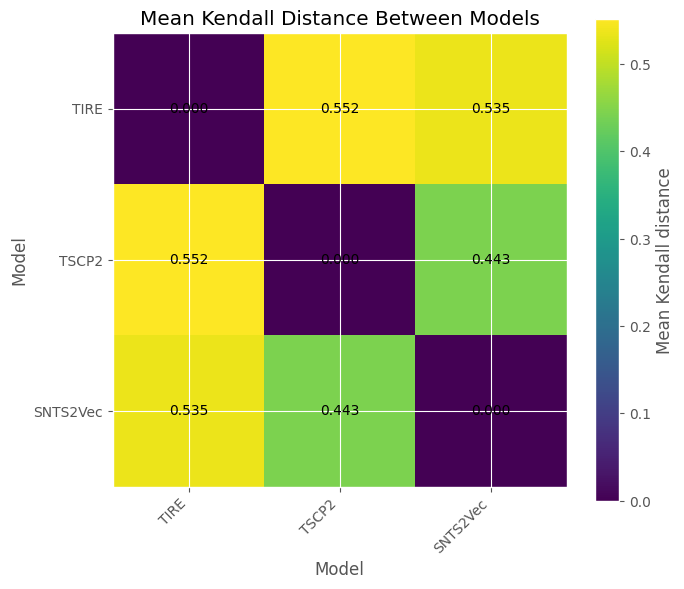

In [55]:
fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(distance_matrix.to_numpy())

ax.set_xticks(range(len(models.keys())))
ax.set_yticks(range(len(models.keys())))

ax.set_xticklabels(models.keys(), rotation=45, ha="right")
ax.set_yticklabels(models.keys())

ax.set_xlabel("Model")
ax.set_ylabel("Model")
ax.set_title("Mean Kendall Distance Between Models")

# Add numeric values to each cell
for row in range(len(models.keys())):
    for col in range(len(models.keys())):
        value = distance_matrix.iloc[row, col]

        if not np.isnan(value):
            ax.text(
                col,
                row,
                f"{value:.3f}",
                ha="center",
                va="center",
                color="black",
            )

fig.colorbar(image, ax=ax, label="Mean Kendall distance")
fig.tight_layout()
plt.show()

## based on changepoint scores

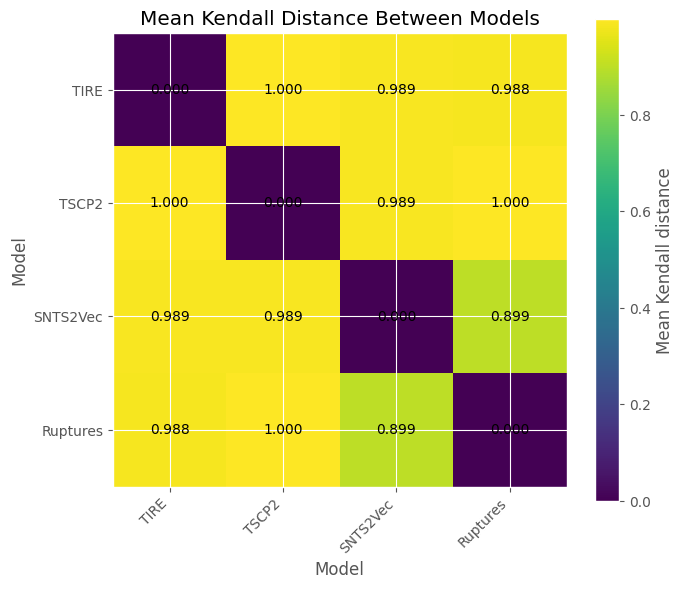

In [56]:
distance_records = []
models = {"TIRE": tire_cps,"TSCP2": t_zeros,"SNTS2Vec": s_zeros,"Ruptures": rpt_cps,}

for ts in range(len(tire_cps)):
    for (name_1, model_1), (name_2, model_2) in combinations_with_replacement(
        models.items(), 2
    ):
        scores_1 = model_1[ts]
        scores_2 = model_2[ts]

        tau, _ = kendalltau(
            scores_1,
            scores_2,
            variant="b",
        )

        #if np.isnan(tau):
        #    print(f"NAN value at series {ts}")

        distance_records.append({
            "series_id": f"series_{ts}",
            "model_1": name_1,
            "model_2": name_2,
            "kendall_tau": tau,
            "distance": 1 - tau,
        })
distances_long = pd.DataFrame(distance_records)

mean_pairwise = (
    distances_long
    .groupby(["model_1", "model_2"], as_index=False)["distance"]
    .mean()
)

model_names = list(models.keys())

mean_pairwise["model_1"] = pd.Categorical(
    mean_pairwise["model_1"],
    categories=model_names,
    ordered=True,
)

mean_pairwise["model_2"] = pd.Categorical(
    mean_pairwise["model_2"],
    categories=model_names,
    ordered=True,
)

distance_matrix = mean_pairwise.pivot(
    index="model_1",
    columns="model_2",
    values="distance",
).reindex(
    index=model_names,
    columns=model_names,
)

distance_matrix = distance_matrix.combine_first(distance_matrix.T)

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(distance_matrix.to_numpy())

ax.set_xticks(range(len(models.keys())))
ax.set_yticks(range(len(models.keys())))

ax.set_xticklabels(models.keys(), rotation=45, ha="right")
ax.set_yticklabels(models.keys())

ax.set_xlabel("Model")
ax.set_ylabel("Model")
ax.set_title("Mean Kendall Distance Between Models")

# Add numeric values to each cell
for row in range(len(models.keys())):
    for col in range(len(models.keys())):
        value = distance_matrix.iloc[row, col]

        if not np.isnan(value):
            ax.text(
                col,
                row,
                f"{value:.3f}",
                ha="center",
                va="center",
                color="black",
            )

fig.colorbar(image, ax=ax, label="Mean Kendall distance")
fig.tight_layout()
plt.show()

In [57]:
distances_long[(distances_long["model_1"] == "SNTS2Vec") & (distances_long["model_2"] == "Ruptures")].sort_values("distance")

,series_id,model_1,model_2,kendall_tau,distance
578,series_57,SNTS2Vec,Ruptures,1.000000,0.000000
468,series_46,SNTS2Vec,Ruptures,1.000000,0.000000
758,series_75,SNTS2Vec,Ruptures,1.000000,0.000000
1868,series_186,SNTS2Vec,Ruptures,1.000000,0.000000
218,series_21,SNTS2Vec,Ruptures,0.706382,0.293618
...,...,...,...,...,...
2048,series_204,SNTS2Vec,Ruptures,NaN,NaN
2078,series_207,SNTS2Vec,Ruptures,NaN,NaN
2108,series_210,SNTS2Vec,Ruptures,NaN,NaN
2158,series_215,SNTS2Vec,Ruptures,NaN,NaN


In [58]:
np.min(distances_long[(distances_long["model_1"] == "TIRE") & (distances_long["model_2"] == "TSCP2")]["distance"])

np.float64(0.5012826434367035)

In [59]:
n = 57
#print(np.argmax(tire_cps[n]))
#print(np.argmax(t_zeros[n]))

print(np.flatnonzero(tire_cps[n]))
print(np.flatnonzero(t_zeros[n]))
print(np.flatnonzero(s_zeros[n]))
print(np.flatnonzero(rpt_cps[n]))

print(np.mean(distances_long[(distances_long["series_id"] == f"series_{n}") & (distances_long["model_1"] != (distances_long["model_2"]))]["distance"]))

[200 314]
[245]
[314]
[314]
0.5986765351324781


In [60]:
ns = []
mean_agree = []
for n in range(224):
    ns.append(n)
    mean_agree.append(np.mean(distances_long[(distances_long["series_id"] == f"series_{n}") & (distances_long["model_1"] != (distances_long["model_2"]))]["distance"]))


In [61]:
agree_df = pd.DataFrame({"ts": ns, "agree": mean_agree})
agree_df.sort_values("agree")

,ts,agree
57,57,0.598677
36,36,0.767400
209,209,0.810589
129,129,0.811575
46,46,0.835466
...,...,...
172,172,1.004759
206,206,1.004778
3,3,1.004862
5,5,1.005164


In [62]:
agree_df[agree_df["agree"] <= 1]

,ts,agree
4,4,0.885706
9,9,0.907753
10,10,0.906415
13,13,0.885708
18,18,0.968979
20,20,0.885706
21,21,0.885117
24,24,0.921294
34,34,0.885289
36,36,0.767400


In [63]:
np.mean(distances_long[(distances_long["series_id"] == f"series_{n}") & (distances_long["model_1"] != (distances_long["model_2"]))]["distance"])

np.float64(1.0036452125563606)

## Clustering based on Ruptures changepoints

In [64]:
k = 5

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(rpt_cps)

c:\Users\cgl_0\anaconda3\envs\gdelt\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [65]:
print(rpt_cps.shape)
print(rpt_cps.dtype)
print(rpt_cps[0][:20])

(224, 489)
float64
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [66]:
changepoints = [np.flatnonzero(row) for row in rpt_cps]

In [67]:
n_clusters = 20

X = gaussian_filter1d(rpt_cps, sigma=5, axis=1)

labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(X)
print(Counter(labels))

np.save("gdelt/clustering_results.npy", labels)

Counter({np.int32(14): 46, np.int32(2): 27, np.int32(5): 25, np.int32(4): 17, np.int32(8): 17, np.int32(16): 10, np.int32(1): 10, np.int32(15): 9, np.int32(9): 9, np.int32(6): 8, np.int32(19): 8, np.int32(10): 6, np.int32(11): 5, np.int32(0): 5, np.int32(12): 5, np.int32(7): 5, np.int32(3): 4, np.int32(18): 4, np.int32(13): 3, np.int32(17): 1})


c:\Users\cgl_0\anaconda3\envs\gdelt\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [68]:
for cluster in range(n_clusters):
    print(f"Cluster {cluster}")
    idx = np.where(labels == cluster)[0]
    print(len(idx))
    print([file_names[i] for i in idx])
    print([changepoints[i] for i in idx])
    print()

Cluster 0
5
['CHN_CHNGOV_data.csv', 'CHN_USA_data.csv', 'CHNGOV_CHN_data.csv', 'GOV_CHN_data.csv', 'USA_CHN_data.csv']
[array([210, 239, 368]), array([208, 368]), array([210, 240, 368]), array([209, 245, 368, 461]), array([ 43, 208, 243, 364])]

Cluster 1
10
['CVL_MIL_data.csv', 'GOV_JUD_data.csv', 'JUD_BUS_data.csv', 'JUD_COP_data.csv', 'MED_GOV_data.csv', 'MIL_CVL_data.csv', 'USA_GOV_data.csv', 'USA_USALEG_data.csv', 'USAEDU_EDU_data.csv', 'USALEG_USA_data.csv']
[array([263]), array([ 54, 270, 463]), array([ 85, 266]), array([206, 264]), array([ 43, 187, 264, 317, 378]), array([172, 261, 316, 366]), array([ 43, 217, 263]), array([ 50, 262]), array([265]), array([ 27, 272])]

Cluster 2
27
['AFR_USA_data.csv', 'BUS_CHN_data.csv', 'BUS_GBR_data.csv', 'BUS_LAB_data.csv', 'BUS_USA_data.csv', 'CHN_GOV_data.csv', 'CRM_COP_data.csv', 'CRM_USA_data.csv', 'CVL_USA_data.csv', 'EDU_GBR_data.csv', 'GBR_GBRGOV_data.csv', 'GBR_IRL_data.csv', 'GOV_BUS_data.csv', 'GOV_IRL_data.csv', 'GOV_OPP_data.csv

In [69]:
print(f"Cluster {cluster}")
idx = np.where(labels == cluster)[0]
print([file_names[i] for i in idx])
print([changepoints[i] for i in idx])
# extract both actors from the filenames
actor1 = [file_names[i].split('_')[0] for i in idx]
actor2 = [file_names[i].split('_')[1] for i in idx]
all_actors = actor1 + actor2
# aggregate the actor counts
from collections import Counter
actor_counts = Counter(all_actors)
print(actor_counts)

Cluster 19
['CVL_CAN_data.csv', 'CVL_GOV_data.csv', 'GBR_EDU_data.csv', 'GOV_CVL_data.csv', 'GOV_PAK_data.csv', 'PAK_GOV_data.csv', 'USA_USACVL_data.csv', 'USA_USAMED_data.csv']
[array([201, 282, 378]), array([204]), array([201]), array([199, 318, 375]), array([203]), array([203]), array([ 53, 206, 332]), array([137, 204, 264])]
Counter({'GOV': 4, 'CVL': 3, 'PAK': 2, 'USA': 2, 'GBR': 1, 'CAN': 1, 'EDU': 1, 'USACVL': 1, 'USAMED': 1})


# Artificial changepoints

In [70]:
Xs = []

data_dir = Path(r"D:/gdelt_data/input_datasets/weekly_pw_filtered_features")
counter = 0
for csv_file in data_dir.glob("*.csv"):

    df = pd.read_csv(csv_file)
    ws_pp = df.copy()
    X = np.column_stack([
        ws_pp['mentions'],
        ws_pp['events'],
        ws_pp['avg_sentenceid'],
        ws_pp['avg_a1co'],
        ws_pp['avg_a2co'],
        ws_pp['avg_actco'],
        ws_pp['avg_raw_text'],
        ws_pp['avg_root_event'],
        ws_pp['avg_len'],
        ws_pp['avg_goldstein'],
        ws_pp['avg_tone'],
        ws_pp['avg_confidence'],
        ws_pp['avg_lat1'],
        ws_pp['avg_lon1'],
        ws_pp['avg_lat2'],
        ws_pp['avg_lon2'],
        ws_pp['avg_lata'],
        ws_pp['avg_lona'],
        ws_pp['total_num_mentions'],
        ws_pp['total_num_sources'],
        ws_pp['total_num_articles'],
    ])

    Xs.append(X)
    #X = (X - X.mean(axis=0)) / X.std(axis=0)
    
train_data = np.array(Xs)

In [71]:
train_data.shape

(224, 489, 21)

In [72]:
"""
# Implementation of artificial anomaly detection using TS2Vec on GDELT data
#Contextual Anomaly. We convolve a the time-series subsequence linear function aY + b, where a ∼ N (1, σ2a) and b ∼ N (0, σ2b)
train_data_modified = train_data.copy()

start_segs = []
end_segs = []

rng = np.random.default_rng(42)

scale_strength = 0.2   # a is usually around 0.8–1.2
shift_strength = 0.4   # shift relative to series standard deviation

min_length = 50
max_length = 250

min_start = 50
max_end = 439

for i in range(train_data.shape[0]):

    segment_length = rng.integers(min_length,min(max_length, train_data.shape[1]) + 1,)
    start_seg = rng.integers(min_start, train_data.shape[1] - segment_length + 1,)
    end_seg = start_seg + segment_length
    end_seg = min(end_seg, max_end)
    start_segs.append(start_seg)
    end_segs.append(end_seg)

    for j in range(train_data.shape[2]):
        series = train_data[i, :, j]
        series_std = np.std(series)

        # Multiplicative change: dimensionless and centered at 1
        a = rng.normal(loc=1.0, scale=scale_strength)

        # Additive change: expressed in the units of the time series
        b = rng.normal(loc=0.0, scale=shift_strength * series_std)

        if j==1:
            print(f"Series {i}, dimension {j}: segment [{start_seg}:{end_seg}], a={a:.3f}, b={b:.3f}")

        train_data_modified[i, start_seg:end_seg, j] = (a * train_data_modified[i, start_seg:end_seg, j] + b)

cp_dict = {
    "start_segs": start_segs,
    "end_segs": end_segs,
}
"""

'\n# Implementation of artificial anomaly detection using TS2Vec on GDELT data\n#Contextual Anomaly. We convolve a the time-series subsequence linear function aY + b, where a ∼ N (1, σ2a) and b ∼ N (0, σ2b)\ntrain_data_modified = train_data.copy()\n\nstart_segs = []\nend_segs = []\n\nrng = np.random.default_rng(42)\n\nscale_strength = 0.2   # a is usually around 0.8–1.2\nshift_strength = 0.4   # shift relative to series standard deviation\n\nmin_length = 50\nmax_length = 250\n\nmin_start = 50\nmax_end = 439\n\nfor i in range(train_data.shape[0]):\n\n    segment_length = rng.integers(min_length,min(max_length, train_data.shape[1]) + 1,)\n    start_seg = rng.integers(min_start, train_data.shape[1] - segment_length + 1,)\n    end_seg = start_seg + segment_length\n    end_seg = min(end_seg, max_end)\n    start_segs.append(start_seg)\n    end_segs.append(end_seg)\n\n    for j in range(train_data.shape[2]):\n        series = train_data[i, :, j]\n        series_std = np.std(series)\n\n       

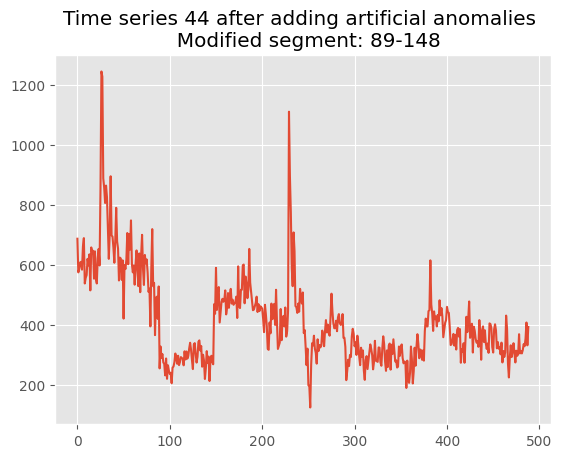

In [73]:
series = 44

train_data_modified = np.load("D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/train_data_modified.npy")
cp_dict = np.load("D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/cp_dict.npy", allow_pickle=True).item()

# plot the first time series after adding artificial anomalies
plt.plot(train_data_modified[series, :, 1])
plt.title(f"Time series {series} after adding artificial anomalies \n  Modified segment: {cp_dict['start_segs'][series]}-{cp_dict['end_segs'][series]}")

#save the modified data and the changepoint dictionary in the external drive
np.save("D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/train_data_modified.npy", train_data_modified)
np.save("D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/cp_dict.npy", cp_dict)

In [74]:
"""
for counter, csv_file in enumerate(data_dir.glob("*.csv")):

    print(f"Processing file {counter + 1}/{len(list(data_dir.glob('*.csv')))}: {csv_file.name}")

    name = csv_file.stem
    modified_file_path = f"D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/{name}.csv"
    new_df = pd.DataFrame(train_data_modified[counter], columns=cols)
    new_df.to_csv(modified_file_path, index=False)
"""

'\nfor counter, csv_file in enumerate(data_dir.glob("*.csv")):\n\n    print(f"Processing file {counter + 1}/{len(list(data_dir.glob(\'*.csv\')))}: {csv_file.name}")\n\n    name = csv_file.stem\n    modified_file_path = f"D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/{name}.csv"\n    new_df = pd.DataFrame(train_data_modified[counter], columns=cols)\n    new_df.to_csv(modified_file_path, index=False)\n'

In [75]:
#introduce a function to calculate the accuracy with a tolerance window of 15 around the true changepoint for both start and end changepoints
def calculate_accuracy_with_tolerance(detected_cps, true_start_cp, true_end_cp, tolerance=15):
    start_correct = any(abs(detected_cp - true_start_cp) <= tolerance for detected_cp in detected_cps)
    end_correct = any(abs(detected_cp - true_end_cp) <= tolerance for detected_cp in detected_cps)
    start_offset = min(abs(detected_cp - true_start_cp) for detected_cp in detected_cps) if detected_cps.size > 0 and start_correct else None
    end_offset = min(abs(detected_cp - true_end_cp) for detected_cp in detected_cps) if detected_cps.size > 0 and end_correct else None
    return start_correct, end_correct, start_offset, end_offset

## ruptures with fake changepoints

In [76]:
rpt_fs_mod = np.load("gdelt/ruptures/ruptures_window_modified_fs.npy")
rpt_cps_mod = np.load("gdelt/ruptures/ruptures_window_modified_cp.npy")

labels = np.load("D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/cp_dict.npy", allow_pickle=True).item()

In [77]:
start_labels = labels["start_segs"]
end_labels = labels["end_segs"]

assert len(start_labels) == len(end_labels) == len(rpt_cps_mod), "Length mismatch between labels and modified data"

correct_start_detections = 0
correct_end_detections = 0

for i in range(len(rpt_cps_mod)):
    start_cp = start_labels[i]
    end_cp = end_labels[i]
    detected_cps = np.flatnonzero(rpt_cps_mod[i])
    if i == 0:
        print(f"Series {i}: Start CP = {start_cp}, End CP = {end_cp}, Detected CPs = {detected_cps}")
    if start_cp in detected_cps:
        correct_start_detections += 1
    if end_cp in detected_cps:
        correct_end_detections += 1

print(f"Accuracy for start changepoint detection: {correct_start_detections / len(rpt_cps_mod) * 100:.2f}%")
print(f"Accuracy for end changepoint detection: {correct_end_detections / len(rpt_cps_mod) * 100:.2f}%")


Series 0: Start CP = 338, End CP = 405, Detected CPs = [ 90 216]
Accuracy for start changepoint detection: 85.71%
Accuracy for end changepoint detection: 87.50%


Series 0: Start CP = 338, End CP = 405, Detected CPs = [ 90 216]
Start Correct: False, End Correct: False, Start Offset: None, End Offset: None
Accuracy for start changepoint detection with tolerance: 97.77%
Accuracy for end changepoint detection with tolerance: 97.77%


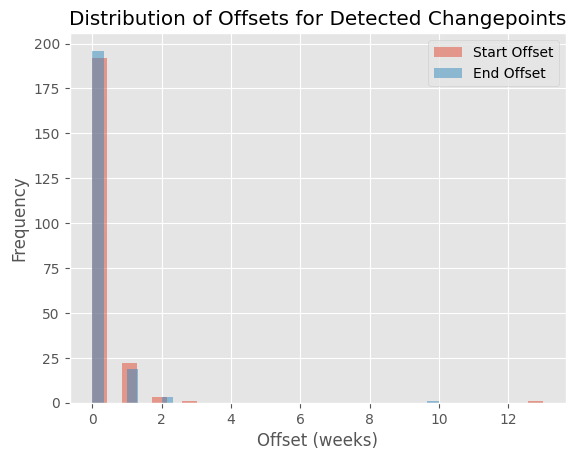

In [78]:
#for i in range(len(rpt_cps_mod)):
#    print(labels["start_segs"][i], labels["end_segs"][i])

# with tolerance window
accuracy_results = []
for i in range(len(rpt_cps_mod)):
    start_cp = start_labels[i]
    end_cp = end_labels[i]
    detected_cps = np.flatnonzero(rpt_cps_mod[i])
    start_correct, end_correct, start_offset, end_offset = calculate_accuracy_with_tolerance(detected_cps, start_cp, end_cp)
    if i == 0:
        print(f"Series {i}: Start CP = {start_cp}, End CP = {end_cp}, Detected CPs = {detected_cps}")
        print(f"Start Correct: {start_correct}, End Correct: {end_correct}, Start Offset: {start_offset}, End Offset: {end_offset}")
    accuracy_results.append((start_correct, end_correct, start_offset, end_offset))
offsets = pd.DataFrame(accuracy_results, columns=["start_correct", "end_correct", "start_offset", "end_offset"])

print(f"Accuracy for start changepoint detection with tolerance: {offsets['start_correct'].mean() * 100:.2f}%")
print(f"Accuracy for end changepoint detection with tolerance: {offsets['end_correct'].mean() * 100:.2f}%")

plt.hist(offsets["start_offset"].dropna(), bins=30, alpha=0.5, label="Start Offset")
plt.hist(offsets["end_offset"].dropna(), bins=30, alpha=0.5, label="End Offset")
plt.title("Distribution of Offsets for Detected Changepoints")
plt.xlabel("Offset (weeks)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## TIRE with the fake changepoints

In [79]:
labels = np.load("D:/gdelt_data/input_datasets/weekly_pw_filtered_features_modified/cp_dict.npy", allow_pickle=True).item()

In [80]:
start_labels = labels["start_segs"]
end_labels = labels["end_segs"]

#assert len(start_labels) == len(end_labels) == len(mod_tire_cps), "Length mismatch between labels and modified data"

correct_start_detections = 0
correct_end_detections = 0

for i in range(len(mod_tire_cps)):
    start_cp = start_labels[i]
    end_cp = end_labels[i]
    detected_cps = np.flatnonzero(mod_tire_cps[i])
    unmodified_cps = np.flatnonzero(tire_cps[i])

    print(f"Series {i}: Start CP = {start_cp}, End CP = {end_cp}, Detected CPs = {detected_cps}, Unmodified CPs = {unmodified_cps}")
    if start_cp in detected_cps:
        correct_start_detections += 1
    if end_cp in detected_cps:
        correct_end_detections += 1

print(f"Accuracy for start changepoint detection: {correct_start_detections / len(mod_tire_cps) * 100:.2f}%")
print(f"Accuracy for end changepoint detection: {correct_end_detections / len(mod_tire_cps) * 100:.2f}%")

Series 0: Start CP = 338, End CP = 405, Detected CPs = [ 91 253 353 428], Unmodified CPs = [130 231 379]
Series 1: Start CP = 293, End CP = 430, Detected CPs = [], Unmodified CPs = [128 280]
Series 2: Start CP = 89, End CP = 283, Detected CPs = [151 370], Unmodified CPs = [129 214 360 438]
Series 3: Start CP = 355, End CP = 439, Detected CPs = [116 235 333 414], Unmodified CPs = [228 347 403]
Series 4: Start CP = 62, End CP = 219, Detected CPs = [126 209 304 377], Unmodified CPs = [129 220 341]
Series 5: Start CP = 227, End CP = 303, Detected CPs = [ 88 246 292], Unmodified CPs = [100 222 348 420]
Series 6: Start CP = 92, End CP = 258, Detected CPs = [], Unmodified CPs = [152 373]
Series 7: Start CP = 168, End CP = 285, Detected CPs = [], Unmodified CPs = [185 371]
Series 8: Start CP = 190, End CP = 344, Detected CPs = [], Unmodified CPs = [ 93 259 414]
Series 9: Start CP = 313, End CP = 439, Detected CPs = [ 58 249 358], Unmodified CPs = [112 248 376]
Series 10: Start CP = 281, End CP

In [81]:
accuracy_results = []
for i in range(len(mod_tire_cps)):
    detected_cps = np.flatnonzero(mod_tire_cps[i])
    start_cp = start_labels[i]
    end_cp = end_labels[i]
    start_correct, end_correct, start_offset, end_offset = calculate_accuracy_with_tolerance(detected_cps, start_cp, end_cp, tolerance=15)
    accuracy_results.append((start_correct, end_correct, start_offset, end_offset))

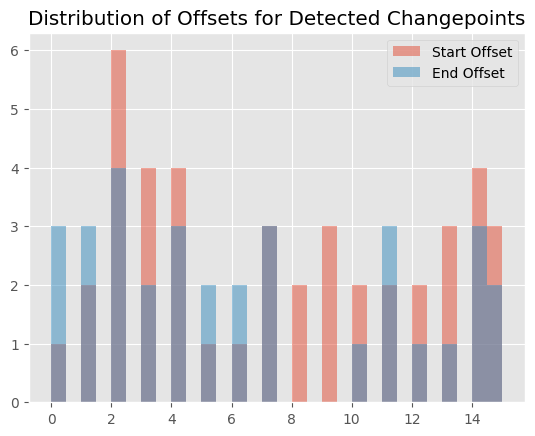

Accuracy for start changepoint detection with tolerance: 19.20%
Accuracy for end changepoint detection with tolerance: 14.73%


In [82]:
accuracy_results
offset_distribution = pd.DataFrame(accuracy_results, columns=["start_correct", "end_correct", "start_offset", "end_offset"])
plt.hist(offset_distribution["start_offset"].dropna(), bins=30, alpha=0.5, label="Start Offset")
plt.hist(offset_distribution["end_offset"].dropna(), bins=30, alpha=0.5, label="End Offset")
plt.title("Distribution of Offsets for Detected Changepoints")
plt.legend()
plt.show()
print(f"Accuracy for start changepoint detection with tolerance: {offset_distribution['start_correct'].mean() * 100:.2f}%")
print(f"Accuracy for end changepoint detection with tolerance: {offset_distribution['end_correct'].mean() * 100:.2f}%")

In [83]:
offset_distribution

,start_correct,end_correct,start_offset,end_offset
0,True,False,15.0,NaN
1,False,False,NaN,NaN
2,False,False,NaN,NaN
3,False,False,NaN,NaN
4,False,True,NaN,10.0
...,...,...,...,...
219,False,False,NaN,NaN
220,False,False,NaN,NaN
221,False,False,NaN,NaN
222,False,False,NaN,NaN


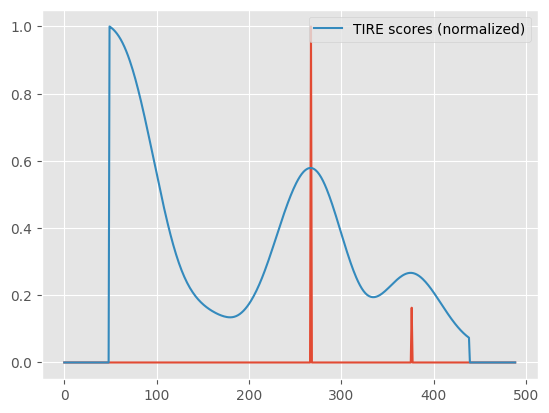

In [84]:
series = 10

plt.plot(mod_tire_cps[series])
plt.plot(mod_tire_fs[series] / np.max(mod_tire_fs[series]), label="TIRE scores (normalized)")
plt.legend()
plt.show()

In [85]:
#for i in range(20):
#    print(f"Series {i}: Ruptures CPs = {np.flatnonzero(rpt_cps_mod[i])}, TIRE CPs = {np.flatnonzero(mod_tire_cps[i])}, Start label = {start_labels[i]}, End label = {end_labels[i]}")
#    print()

## SNTS2Vec with fake changepoints

In [86]:
start_labels = labels["start_segs"]
end_labels = labels["end_segs"]

assert len(start_labels) == len(end_labels) == len(s_zeros_mod), "Length mismatch between labels and modified data"

correct_start_detections = 0
correct_end_detections = 0

for i in range(len(s_zeros_mod)):
    start_cp = start_labels[i]
    end_cp = end_labels[i]
    detected_cps = np.flatnonzero(s_zeros_mod[i])
    if start_cp in detected_cps:
        correct_start_detections += 1
    if end_cp in detected_cps:
        correct_end_detections += 1

print(f"Accuracy for start changepoint detection: {correct_start_detections / len(s_zeros_mod) * 100:.2f}%")
print(f"Accuracy for end changepoint detection: {correct_end_detections / len(s_zeros_mod) * 100:.2f}%")

Accuracy for start changepoint detection: 69.64%
Accuracy for end changepoint detection: 52.68%


Series 0: Start CP = 338, End CP = 405, Detected CPs = []
Start Correct: False, End Correct: False, Start Offset: None, End Offset: None
Accuracy for start changepoint detection with tolerance: 72.32%
Accuracy for end changepoint detection with tolerance: 67.41%


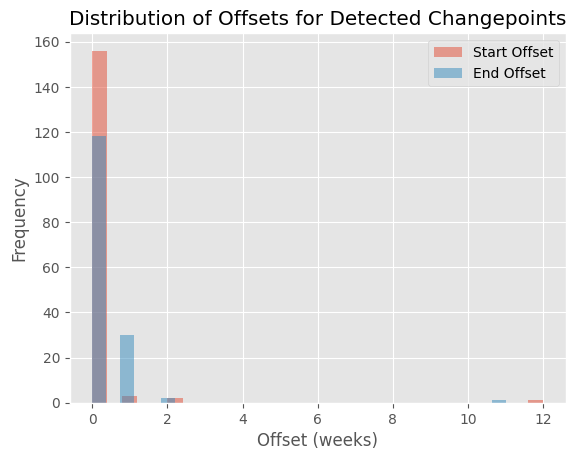

In [87]:
accuracy_results = []
for i in range(len(s_zeros_mod)):
    start_cp = start_labels[i]
    end_cp = end_labels[i]
    detected_cps = np.flatnonzero(s_zeros_mod[i])
    start_correct, end_correct, start_offset, end_offset = calculate_accuracy_with_tolerance(detected_cps, start_cp, end_cp)
    if i == 0:
        print(f"Series {i}: Start CP = {start_cp}, End CP = {end_cp}, Detected CPs = {detected_cps}")
        print(f"Start Correct: {start_correct}, End Correct: {end_correct}, Start Offset: {start_offset}, End Offset: {end_offset}")
    accuracy_results.append((start_correct, end_correct, start_offset, end_offset))
offsets = pd.DataFrame(accuracy_results, columns=["start_correct", "end_correct", "start_offset", "end_offset"])

print(f"Accuracy for start changepoint detection with tolerance: {offsets['start_correct'].mean() * 100:.2f}%")
print(f"Accuracy for end changepoint detection with tolerance: {offsets['end_correct'].mean() * 100:.2f}%")

plt.hist(offsets["start_offset"].dropna(), bins=30, alpha=0.5, label="Start Offset")
plt.hist(offsets["end_offset"].dropna(), bins=30, alpha=0.5, label="End Offset")
plt.title("Distribution of Offsets for Detected Changepoints")
plt.xlabel("Offset (weeks)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## tscp2 with fake changepoints

In [88]:
start_labels = labels["start_segs"]
end_labels = labels["end_segs"]

assert len(start_labels) == len(end_labels) == len(t_zeros_mod), "Length mismatch between labels and modified data"

correct_start_detections = 0
correct_end_detections = 0

for i in range(len(t_zeros_mod)):
    start_cp = start_labels[i]
    end_cp = end_labels[i]
    detected_cps = np.flatnonzero(t_zeros_mod[i])
    if start_cp in detected_cps:
        correct_start_detections += 1
        print(f"Series {i}: Start CP = {start_cp}, Detected CPs = {detected_cps}")
    if end_cp in detected_cps:
        correct_end_detections += 1
        print(f"Series {i}: End CP = {end_cp}, Detected CPs = {detected_cps}")

print(f"Accuracy for start changepoint detection: {correct_start_detections / len(t_zeros_mod) * 100:.2f}%")
print(f"Accuracy for end changepoint detection: {correct_end_detections / len(t_zeros_mod) * 100:.2f}%")

Series 7: End CP = 285, Detected CPs = [138 285 380]
Series 12: Start CP = 98, Detected CPs = [ 98 226 309 375]
Series 17: Start CP = 184, Detected CPs = [184 370]
Series 20: End CP = 238, Detected CPs = [ 98 152 238 302 368]
Series 34: Start CP = 207, Detected CPs = [ 75 207 308 412]
Series 55: Start CP = 238, Detected CPs = [134 238 376]
Series 58: Start CP = 135, Detected CPs = [135 300]
Series 61: End CP = 241, Detected CPs = [149 241 377]
Series 65: End CP = 421, Detected CPs = [134 218 267 374 421]
Series 69: End CP = 195, Detected CPs = [ 81 195 310 395]
Series 106: Start CP = 190, Detected CPs = [ 49 190 335]
Series 110: End CP = 286, Detected CPs = [205 286 376 426]
Series 111: End CP = 377, Detected CPs = [145 217 321 377]
Series 140: End CP = 319, Detected CPs = [148 263 319 375]
Series 158: End CP = 390, Detected CPs = [207 390]
Series 187: End CP = 213, Detected CPs = [114 213 358]
Series 191: End CP = 395, Detected CPs = [204 395]
Accuracy for start changepoint detection:

Series 0: Start CP = 338, End CP = 405, Detected CPs = [118 210 334 416]
Start Correct: True, End Correct: True, Start Offset: 4, End Offset: 11
Accuracy for start changepoint detection with tolerance: 62.50%
Accuracy for end changepoint detection with tolerance: 66.96%


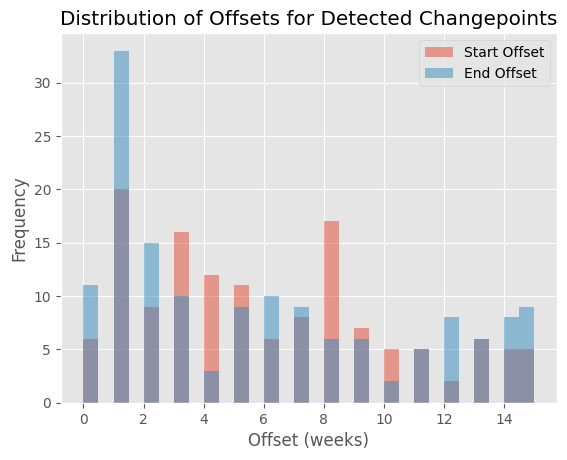

In [89]:
accuracy_results = []
for i in range(len(t_zeros_mod)):
    start_cp = start_labels[i]
    end_cp = end_labels[i]
    detected_cps = np.flatnonzero(t_zeros_mod[i])
    start_correct, end_correct, start_offset, end_offset = calculate_accuracy_with_tolerance(detected_cps, start_cp, end_cp)
    if i == 0:
        print(f"Series {i}: Start CP = {start_cp}, End CP = {end_cp}, Detected CPs = {detected_cps}")
        print(f"Start Correct: {start_correct}, End Correct: {end_correct}, Start Offset: {start_offset}, End Offset: {end_offset}")
    accuracy_results.append((start_correct, end_correct, start_offset, end_offset))
offsets = pd.DataFrame(accuracy_results, columns=["start_correct", "end_correct", "start_offset", "end_offset"])

print(f"Accuracy for start changepoint detection with tolerance: {offsets['start_correct'].mean() * 100:.2f}%")
print(f"Accuracy for end changepoint detection with tolerance: {offsets['end_correct'].mean() * 100:.2f}%")

plt.hist(offsets["start_offset"].dropna(), bins=30, alpha=0.5, label="Start Offset")
plt.hist(offsets["end_offset"].dropna(), bins=30, alpha=0.5, label="End Offset")
plt.title("Distribution of Offsets for Detected Changepoints")
plt.xlabel("Offset (weeks)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Model score ensembling

This is based on Stepikin et. al. (A Window Wasserstein-based aggregation for ensemble change point detection)

In [90]:
n = 8

model_1 = tire_fs[n]
model_2 = tscp2_cps[n]
model_3 = snts_fs[n]

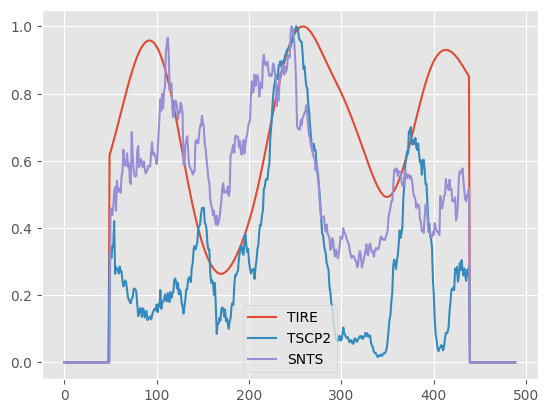

In [91]:
plt.plot(model_1 / np.max(model_1), label="TIRE")
plt.plot(model_2 / np.max(model_2), label="TSCP2")
plt.plot(model_3 / np.max(model_3), label="SNTS")
plt.legend()

In [92]:
wasserstein_distance([0,1,2], [0,1,8])  # Example usage

np.float64(2.0)

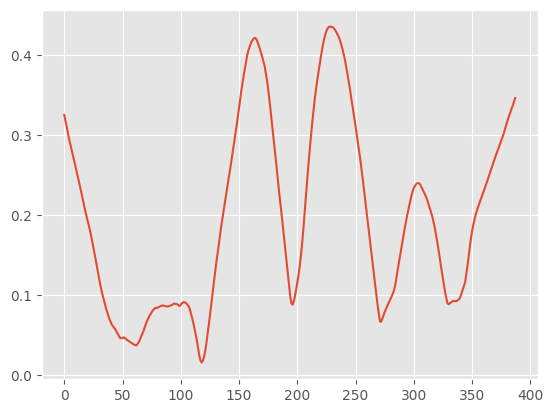

In [93]:
assert len(model_1) == len(model_2) == len(model_3), "Models have different lengths"
w = 50

distances = []

for t in range(2*w + 1, len(model_1)):
    future = np.array([model_1[t-w:t], model_2[t-w:t], model_3[t-w:t]])
    history = np.array([model_1[t-2*w:t-w], model_2[t-2*w:t-w], model_3[t-2*w:t-w]])

    #print(future.shape, history.shape)

    future_flat = future.flatten()
    history_flat = history.flatten()

    d = wasserstein_distance(future_flat, history_flat)
    distances.append(d)
    #print(f"Time {t}: Wasserstein distance = {d:.4f}")

plt.plot(distances)

In [94]:
for n in range(224):

    model_1 = tire_fs[n]
    model_2 = tscp2_cps[n]
    model_3 = snts_fs[n]

    models = [
        np.asarray(model_1, dtype=float),
        np.asarray(model_2, dtype=float),
        np.asarray(model_3, dtype=float),
    ]

    n = len(models[0])
    w = 50
    h = 0.3  # Example threshold; ideally determine on validation data

    assert n >= 2 * w, "Sequence is too short for the chosen window size"

    # Shape: (time, models)
    predictions = np.column_stack(models)

    # WWAggr score for each time. Earlier values are undefined.
    ww_scores = np.full(n, np.nan)

    for t in range(2 * w, n + 1):
        # Both arrays have shape (w, number_of_models)
        past = predictions[t - 2 * w:t - w, :]
        future = predictions[t - w:t, :]

        assert past.shape == future.shape == (w, len(models))

        past_flat = past.ravel()
        future_flat = future.ravel()

        # Store the score at the final time represented by the future window
        score_index = t - 1
        ww_scores[score_index] = wasserstein_distance(
            past_flat,
            future_flat,
        )

    # First threshold crossing
    crossings = np.flatnonzero(ww_scores >= h)

    if len(crossings) == 0:
        change_point = None
        print("No change point detected.")
    else:
        change_point = int(crossings[0])
        print(
            f"First change point detected at index {change_point}; "
            f"Wasserstein score = {ww_scores[change_point]:.4f}"
        )

First change point detected at index 291; Wasserstein score = 0.3060
First change point detected at index 253; Wasserstein score = 0.3016
First change point detected at index 280; Wasserstein score = 0.3068
First change point detected at index 404; Wasserstein score = 0.3052
First change point detected at index 405; Wasserstein score = 0.3072
First change point detected at index 309; Wasserstein score = 0.3011
First change point detected at index 403; Wasserstein score = 0.3102
No change point detected.
First change point detected at index 99; Wasserstein score = 0.3317
First change point detected at index 265; Wasserstein score = 0.3020
No change point detected.
No change point detected.
No change point detected.
First change point detected at index 145; Wasserstein score = 0.3045
First change point detected at index 389; Wasserstein score = 0.3085
No change point detected.
First change point detected at index 244; Wasserstein score = 0.3018
First change point detected at index 250; W

In [95]:
cps = []
all_distances = []
all_locations = []
    
for n in range(224):

    model_1 = tire_fs[n] / np.max(tire_fs[n])
    model_2 = tscp2_cps[n] / np.max(tscp2_cps[n])
    model_3 = snts_fs[n] / np.max(snts_fs[n])
    model_4 = rpt_fs[n] / np.max(rpt_fs[n])

    models = [
        np.asarray(model_1, dtype=float),
        np.asarray(model_2, dtype=float),
        np.asarray(model_3, dtype=float),
        np.asarray(model_4, dtype=float),
    ]

    assert len(model_1) == len(model_2) == len(model_3) == len(model_4), \
        "Models have different lengths"

    w = 50
    h = 0.3  # alarm threshold
    padding = 50

    # Corresponds to:
    # Set w_1 = ... = w_{2ω} = 0
    distances = []
    locations = []

    start_t = padding + 2 * w
    end_t = len(model_1) - padding + 1

    for t in range(start_t, end_t):
        future = np.array([
            model_1[t-w:t],
            model_2[t-w:t],
            model_3[t-w:t],
            model_4[t-w:t]
        ])

        history = np.array([
            model_1[t-2*w:t-w],
            model_2[t-2*w:t-w],
            model_3[t-2*w:t-w],
            model_4[t-2*w:t-w]
        ])

        d = wasserstein_distance(
            future.flatten(),
            history.flatten()
        )

        distances.append(d)
        locations.append(t - w)

    # distances[t] now corresponds directly to timestep t
    #plt.plot(distances)
    #plt.axhline(h, linestyle="--")
    #plt.xlabel("Time")
    #plt.ylabel("Wasserstein distance")

    # Final CP estimate from the pseudocode
    change_point = np.argmax(distances)
    print(f"Predicted change point τ = {change_point}; Wasserstein score = {distances[change_point]:.4f}")
    cps.append(change_point)
    all_distances.append(distances)
    all_locations.append(locations)
#plt.show()

Predicted change point τ = 153; Wasserstein score = 0.3725
Predicted change point τ = 104; Wasserstein score = 0.3259
Predicted change point τ = 140; Wasserstein score = 0.3041
Predicted change point τ = 259; Wasserstein score = 0.2500
Predicted change point τ = 7; Wasserstein score = 0.3263
Predicted change point τ = 161; Wasserstein score = 0.3054
Predicted change point τ = 258; Wasserstein score = 0.2928
Predicted change point τ = 250; Wasserstein score = 0.2933
Predicted change point τ = 108; Wasserstein score = 0.3363
Predicted change point τ = 182; Wasserstein score = 0.3406
Predicted change point τ = 152; Wasserstein score = 0.2658
Predicted change point τ = 177; Wasserstein score = 0.2885
Predicted change point τ = 199; Wasserstein score = 0.2634
Predicted change point τ = 165; Wasserstein score = 0.4281
Predicted change point τ = 165; Wasserstein score = 0.2634
Predicted change point τ = 154; Wasserstein score = 0.3522
Predicted change point τ = 101; Wasserstein score = 0.3506

C:\Users\cgl_0\AppData\Local\Temp\ipykernel_65440\57017670.py:7: RuntimeWarning: invalid value encountered in divide
  model_1 = tire_fs[n] / np.max(tire_fs[n])


In [96]:
#for n in range(224):
#    clear_output(wait=True)

#    plt.figure(figsize=(10,4))
#    plt.plot(all_locations[n], all_distances[n])
#    plt.xlabel("Candidate change-point location")
#    plt.ylabel("Wasserstein distance")
#    plt.grid(alpha=0.3)

##    plt.show()
#    time.sleep(0.5)

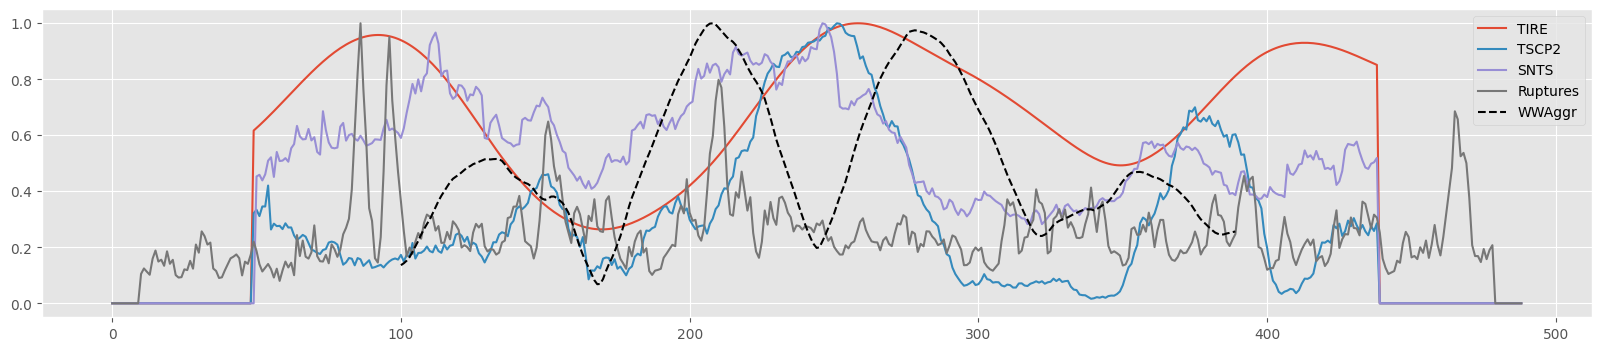

In [97]:
n = 8

plt.figure(figsize=(20,4))
plt.plot(tire_fs[n] / np.max(tire_fs[n]), label="TIRE")
plt.plot(tscp2_cps[n] / np.max(tscp2_cps[n]), label="TSCP2")
plt.plot(snts_fs[n] / np.max(snts_fs[n]), label="SNTS")
plt.plot(rpt_fs[n] / np.max(rpt_fs[n]), label="Ruptures")

#plt.plot(np.mean([tire_fs[n], tscp2_cps[n], snts_fs[n], rpt_fs[n]], axis=0) / np.max(np.mean([tire_fs[n], tscp2_cps[n], snts_fs[n], rpt_fs[n]], axis=0)), label="WWAggr", color="black", linestyle="--")
plt.plot(all_locations[n], all_distances[n] / np.max(all_distances[n]), label="WWAggr", color="black", linestyle="--")
plt.legend()
plt.show()


## Graph of samples

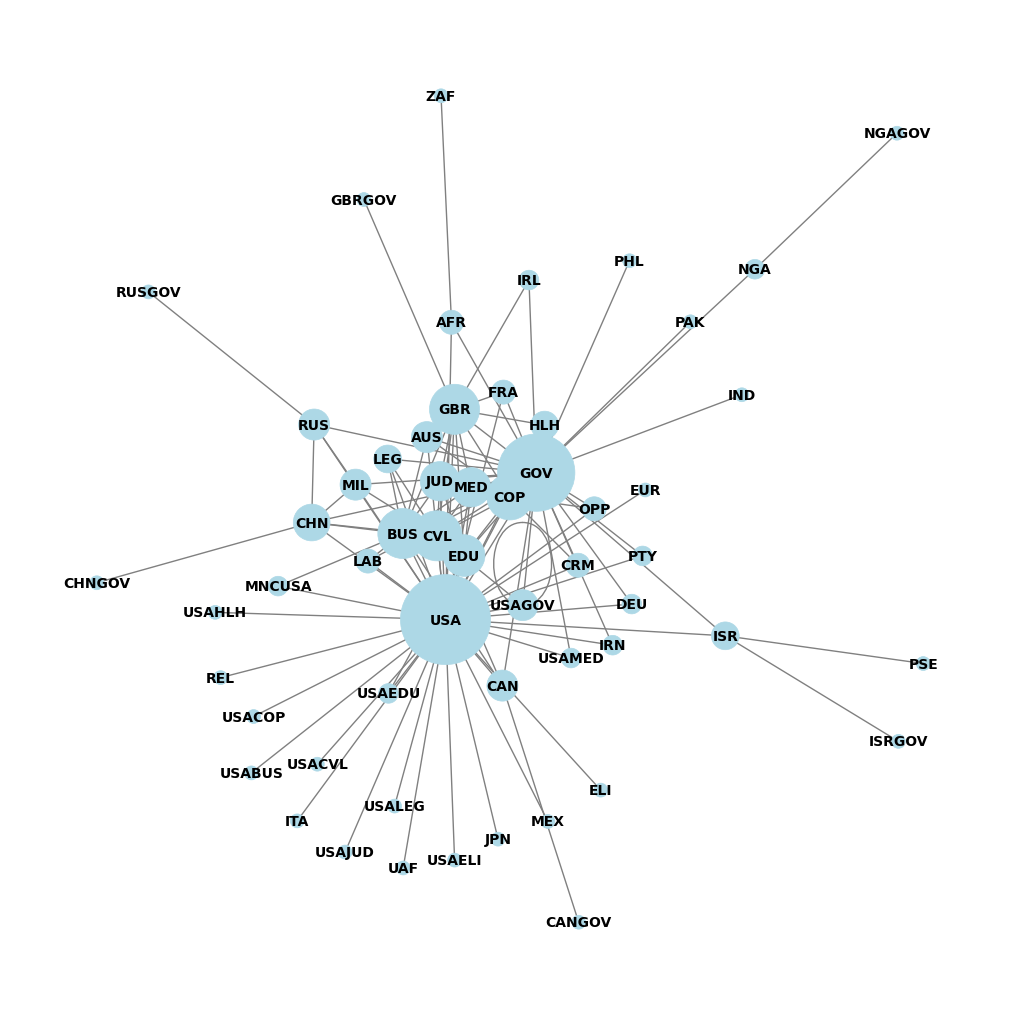

In [98]:
file_names
# extract the actors from the file names (what comes before the first underscore is actor 1 and what comes after until the second underscore is actor 2)
actors = [(f.split("_")[0], f.split("_")[1]) for f in file_names]

#construct graph with actors as nodes and edges between them if they have a file together
G = nx.Graph()
for actor1, actor2 in actors:
    G.add_node(actor1)
    G.add_node(actor2)
    G.add_edge(actor1, actor2)
# visualize the graph
plt.figure(figsize=(10,10))
#pos = nx.circular_layout(G)
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
# size of nodes based on degree
node_sizes = [G.degree(node) * 100 for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_size=node_sizes, node_color="lightblue", font_size=10, font_weight="bold", edge_color="gray")
plt.show()

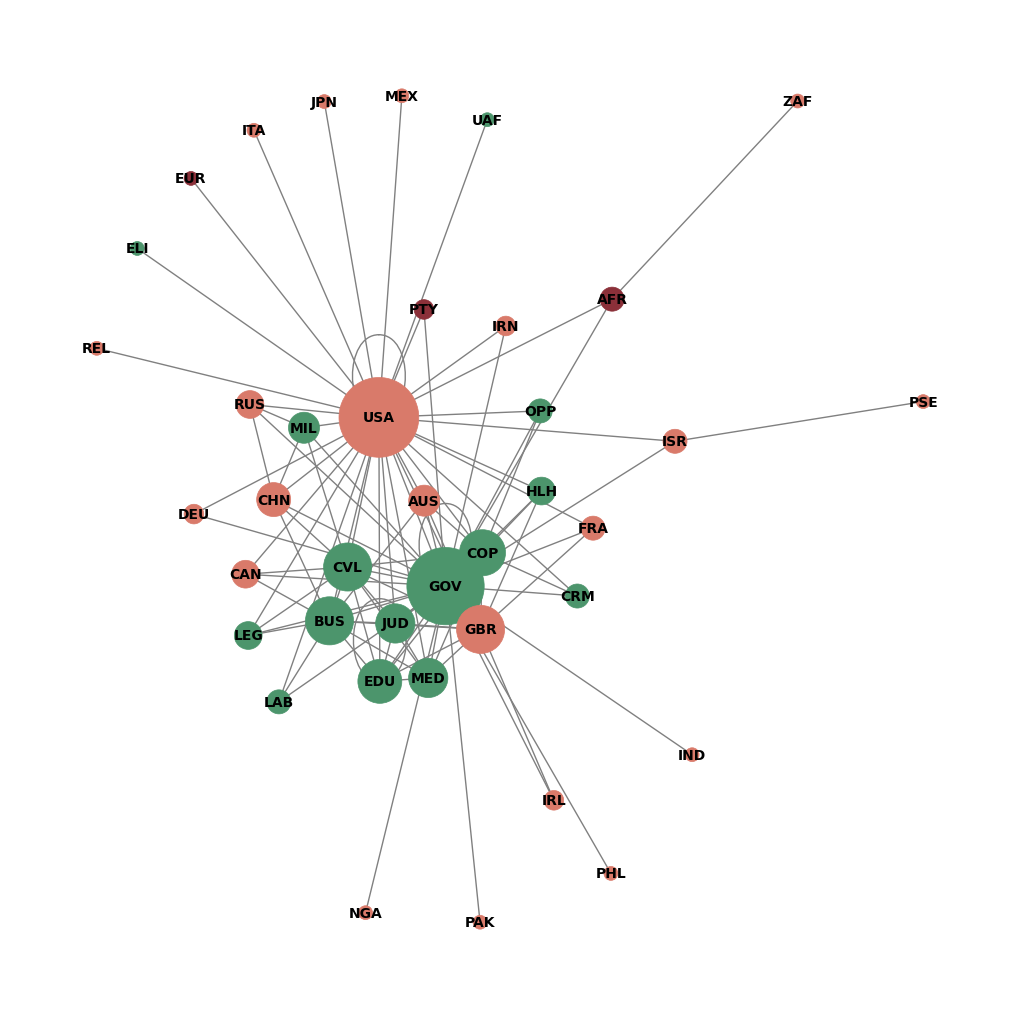

In [99]:
actors_modified = actors.copy()

for i, (actor1, actor2) in enumerate(actors_modified):
    if len(actor1) > 3:
        actor1 = actor1[-3:]
    if len(actor2) > 3:
        actor2 = actor2[-3:]
    actors_modified[i] = (actor1, actor2)

G = nx.Graph()
for actor1, actor2 in actors_modified:
    G.add_node(actor1)
    G.add_node(actor2)
    G.add_edge(actor1, actor2)
# visualize the graph
plt.figure(figsize=(10,10))
#pos = nx.circular_layout(G)
pos = nx.spring_layout(G, seed=42, k=1.5 / max(len(G.nodes()) ** 0.5, 1), iterations=300)  # positions for all nodes
# size of nodes based on degree
node_sizes = [G.degree(node) * 100 for node in G.nodes()]
#color according to type: countries in red, institutions in green, regions in darker red
other = ["AFR", "EUR", "PTY"]

node_colors = []
for node in G.nodes():
    if node in INST:
        node_colors.append("#4C956C")   # muted green
    elif node in other:
        node_colors.append("#8B3039")   # dark muted red
    else:
        node_colors.append("#D97A6A")   # muted salmon/red


#node_colors = ["green" if node in institutions else "darkred" if node in other else "red" for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_size=node_sizes, node_color=node_colors, font_size=10, font_weight="bold", edge_color="gray")
plt.show()




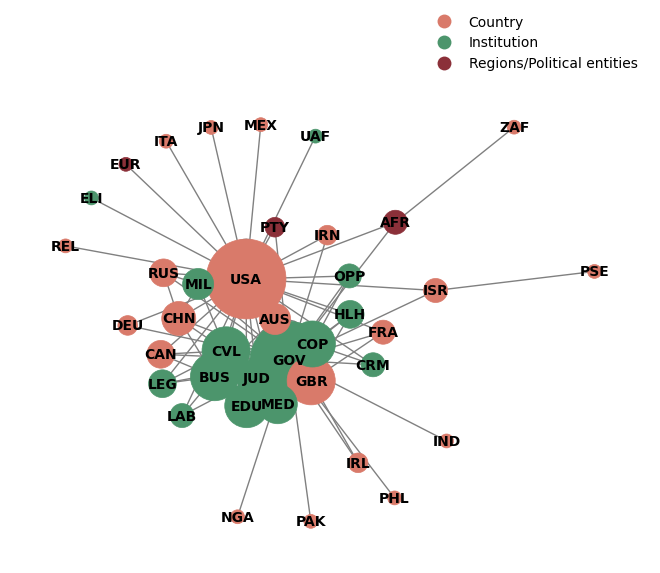

In [100]:
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        label='Country',
        markerfacecolor='#D97A6A',
        markeredgecolor='none',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        label='Institution',
        markerfacecolor='#4C956C',
        markeredgecolor='none',
        markersize=10
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        label='Region / Other',
        markerfacecolor='#8B3039',
        markeredgecolor='none',
        markersize=10
    )
]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes,
    node_color=node_colors,
    font_size=10,
    font_weight="bold",
    edge_color="gray"
)

legend_elements = [
    Line2D([0], [0], marker='o', linestyle='None',
           label='Country', markerfacecolor='#D97A6A',
           markeredgecolor='none', markersize=10),

    Line2D([0], [0], marker='o', linestyle='None',
           label='Institution', markerfacecolor='#4C956C',
           markeredgecolor='none', markersize=10),

    Line2D([0], [0], marker='o', linestyle='None',
           label='Regions/Political entities', markerfacecolor='#8B3039',
           markeredgecolor='none', markersize=10)
]

plt.legend(handles=legend_elements, loc="lower right", frameon=False, bbox_to_anchor=(1, 1))
plt.show()

# CORD CPD evaluation

In [103]:
cluster_labels = np.load("gdelt/clustering_results.npy")

In [124]:
def cord_distance_to_model(cord_cps, model_cluster_cps):
    """
    cord_cps: iterable of CorD changepoint indices
    model_cluster_cps: 2D array (actor_pairs x time)

    Returns one mean nearest-distance per CorD changepoint.
    """

    distances = []

    for cord_cp in cord_cps:
        pair_distances = []

        for pair_cps in model_cluster_cps:
            cp_times = np.flatnonzero(pair_cps)

            if len(cp_times) == 0:
                pair_distances.append(np.nan)
            else:
                nearest = np.min(np.abs(cp_times - cord_cp))
                pair_distances.append(nearest)

        distances.append(np.nanmean(pair_distances))

    return distances

Change points for cluster 0: [208], MSE: [208], Relation: [117]
Cluster members: ['CHN_CHNGOV_data.csv', 'CHN_USA_data.csv', 'CHNGOV_CHN_data.csv', 'GOV_CHN_data.csv', 'USA_CHN_data.csv']
Cluster 0
TIRE: [np.float64(47.0)]
SN-TS2Vec: [np.float64(113.0)]
TS-CP2: [np.float64(68.4)]
Ruptures: [np.float64(1.0)]


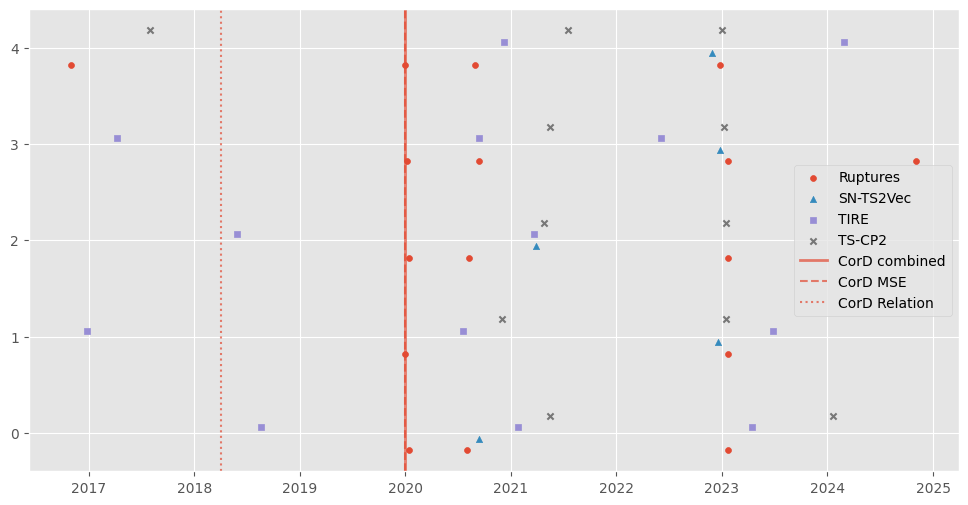

Change points for cluster 1: [56], MSE: [56], Relation: [293]
Cluster members: ['CVL_MIL_data.csv', 'GOV_JUD_data.csv', 'JUD_BUS_data.csv', 'JUD_COP_data.csv', 'MED_GOV_data.csv', 'MIL_CVL_data.csv', 'USA_GOV_data.csv', 'USA_USALEG_data.csv', 'USAEDU_EDU_data.csv', 'USALEG_USA_data.csv']
Cluster 1
TIRE: [np.float64(105.4)]
SN-TS2Vec: [np.float64(252.0)]
TS-CP2: [np.float64(189.2)]
Ruptures: [np.float64(77.4)]


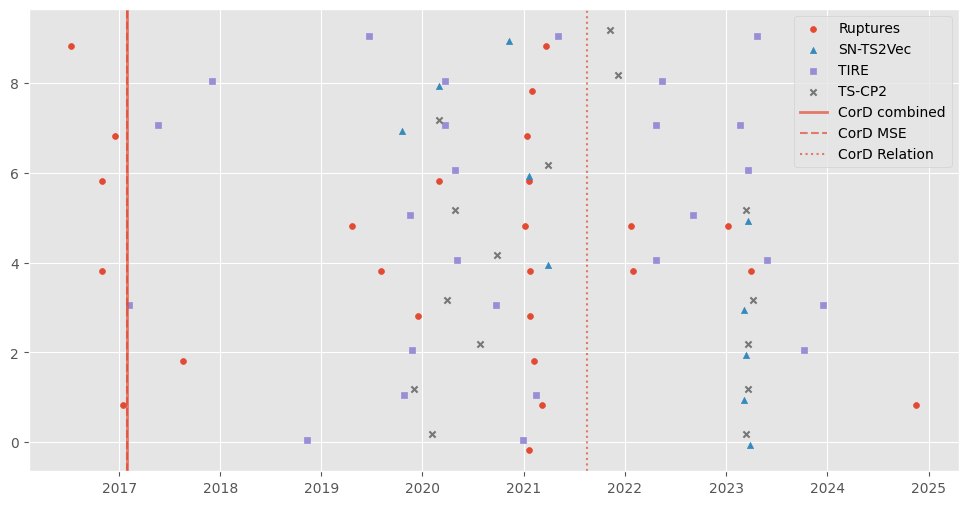

Change points for cluster 2: [26], MSE: [26], Relation: [113]
Cluster members: ['AFR_USA_data.csv', 'BUS_CHN_data.csv', 'BUS_GBR_data.csv', 'BUS_LAB_data.csv', 'BUS_USA_data.csv', 'CHN_GOV_data.csv', 'CRM_COP_data.csv', 'CRM_USA_data.csv', 'CVL_USA_data.csv', 'EDU_GBR_data.csv', 'GBR_GBRGOV_data.csv', 'GBR_IRL_data.csv', 'GOV_BUS_data.csv', 'GOV_IRL_data.csv', 'GOV_OPP_data.csv', 'HLH_COP_data.csv', 'HLH_USA_data.csv', 'IRL_GBR_data.csv', 'IRN_USA_data.csv', 'JUD_EDU_data.csv', 'LAB_GOV_data.csv', 'LAB_USA_data.csv', 'OPP_GOV_data.csv', 'PTY_GOV_data.csv', 'USA_AFR_data.csv', 'USA_BUS_data.csv', 'USA_LAB_data.csv']
Cluster 2
TIRE: [np.float64(100.96296296296296)]
SN-TS2Vec: [np.float64(226.59259259259258)]
TS-CP2: [np.float64(242.15384615384616)]
Ruptures: [np.float64(141.62962962962962)]


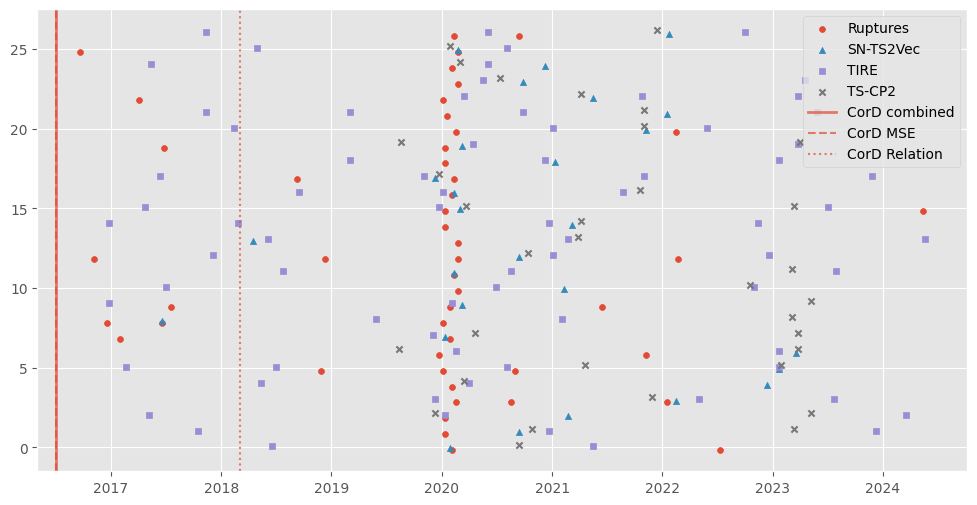

Change points for cluster 3: [369], MSE: [369], Relation: [424]
Cluster members: ['AUS_BUS_data.csv', 'AUS_GOV_data.csv', 'COP_AUS_data.csv', 'GOV_AUS_data.csv']
Cluster 3
TIRE: [np.float64(30.5)]
SN-TS2Vec: [np.float64(6.0)]
TS-CP2: [np.float64(23.25)]
Ruptures: [np.float64(7.0)]


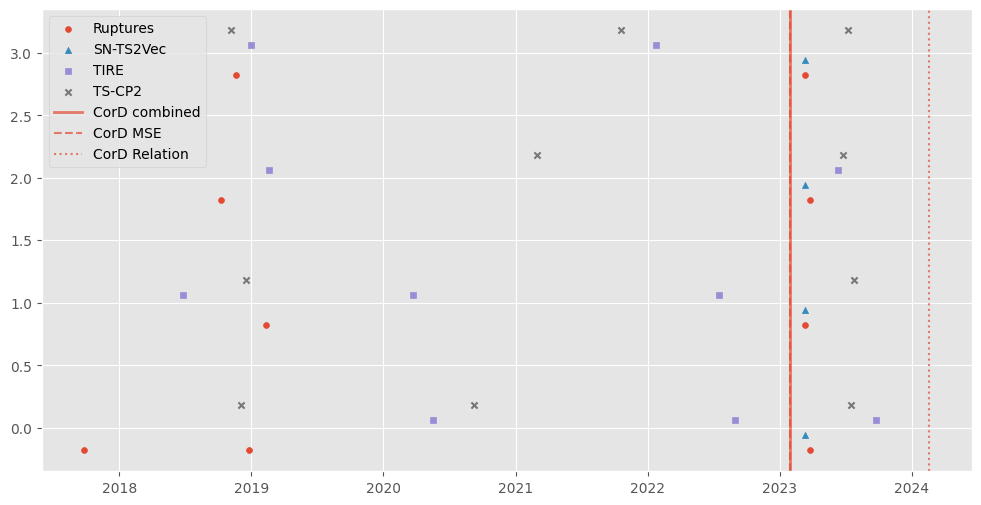

Change points for cluster 4: [60], MSE: [60], Relation: [319]
Cluster members: ['BUS_GOV_data.csv', 'CAN_GOV_data.csv', 'CHN_RUS_data.csv', 'CVL_GBR_data.csv', 'EDU_GOV_data.csv', 'FRA_USA_data.csv', 'GBR_GOV_data.csv', 'GOV_GBR_data.csv', 'GOV_RUS_data.csv', 'GOV_USAMED_data.csv', 'MIL_GOV_data.csv', 'NGA_NGAGOV_data.csv', 'RUS_GOV_data.csv', 'RUS_RUSGOV_data.csv', 'RUS_USA_data.csv', 'RUSGOV_RUS_data.csv', 'USA_RUS_data.csv']
Cluster 4
TIRE: [np.float64(115.52941176470588)]
SN-TS2Vec: [np.float64(252.35294117647058)]
TS-CP2: [np.float64(180.5625)]
Ruptures: [np.float64(155.52941176470588)]


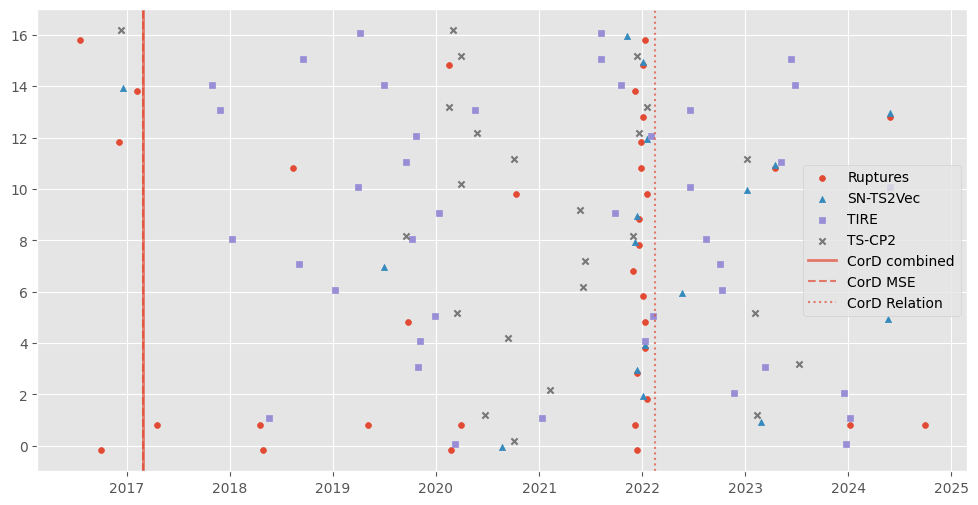

Change points for cluster 5: [223], MSE: [223], Relation: [109]
Cluster members: ['COP_CVL_data.csv', 'COP_EDU_data.csv', 'COP_HLH_data.csv', 'CVL_COP_data.csv', 'EDU_COP_data.csv', 'GBR_COP_data.csv', 'GBR_HLH_data.csv', 'GBR_MED_data.csv', 'GOV_AFR_data.csv', 'GOV_CRM_data.csv', 'GOV_EDU_data.csv', 'GOV_LAB_data.csv', 'GOV_PTY_data.csv', 'JUD_GBR_data.csv', 'LEG_BUS_data.csv', 'MED_COP_data.csv', 'MED_GBR_data.csv', 'MEX_USA_data.csv', 'MIL_USA_data.csv', 'OPP_USA_data.csv', 'USA_EDU_data.csv', 'USA_OPP_data.csv', 'USA_USACOP_data.csv', 'USA_USAEDU_data.csv', 'USACOP_USA_data.csv']
Cluster 5
TIRE: [np.float64(16.4)]
SN-TS2Vec: [np.float64(31.32)]
TS-CP2: [np.float64(27.17391304347826)]
Ruptures: [np.float64(4.36)]


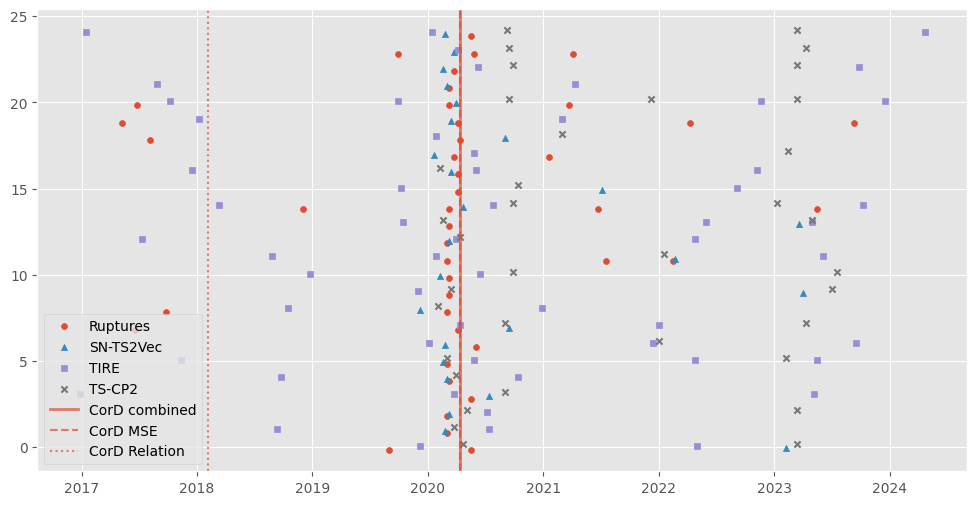

Change points for cluster 6: [58], MSE: [58], Relation: [38]
Cluster members: ['BUS_CVL_data.csv', 'EDU_CVL_data.csv', 'ELI_USA_data.csv', 'GBR_BUS_data.csv', 'USA_MED_data.csv', 'USACVL_USA_data.csv', 'USAGOV_CVL_data.csv', 'USAGOV_USAGOV_data.csv']
Cluster 6
TIRE: [np.float64(90.75)]
SN-TS2Vec: [np.float64(218.875)]
TS-CP2: [np.float64(174.125)]
Ruptures: [np.float64(3.5)]


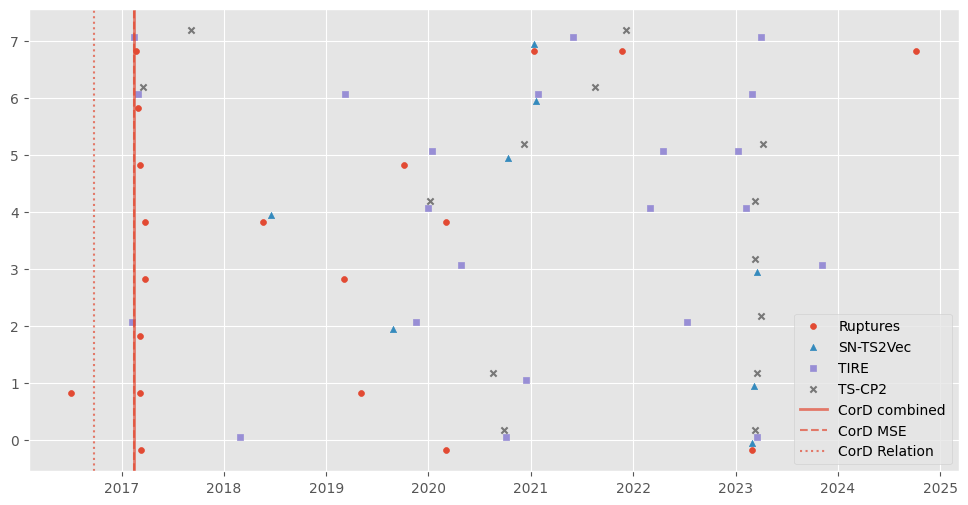

Change points for cluster 7: [118], MSE: [118], Relation: [89]
Cluster members: ['ISR_GOV_data.csv', 'ISR_USA_data.csv', 'MNCUSA_USA_data.csv', 'RUS_MIL_data.csv', 'USA_UAF_data.csv']
Cluster 7
TIRE: [np.float64(31.0)]
SN-TS2Vec: [np.float64(212.6)]
TS-CP2: [np.float64(93.2)]
Ruptures: [np.float64(233.0)]


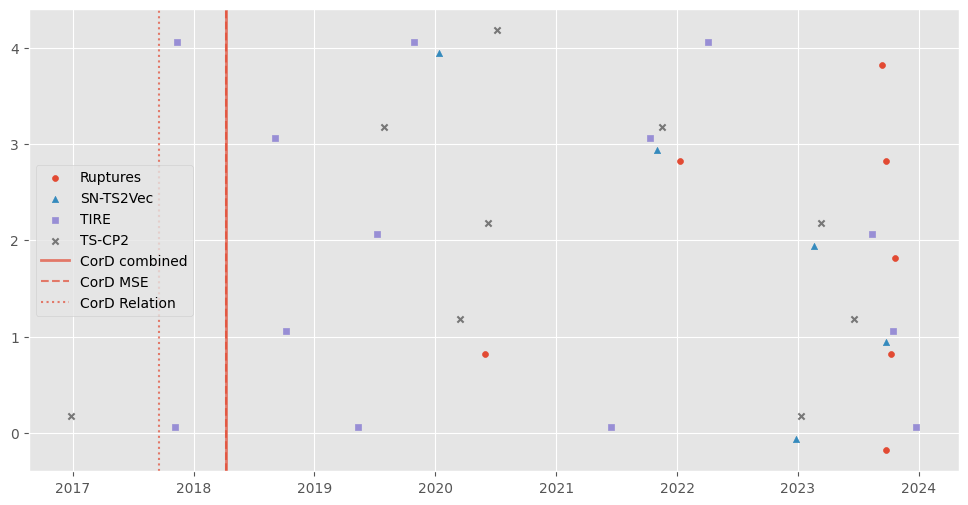

Change points for cluster 8: [103], MSE: [103], Relation: [95]
Cluster members: ['BUS_MED_data.csv', 'BUS_MNCUSA_data.csv', 'CHN_CVL_data.csv', 'CVL_MED_data.csv', 'EDU_MED_data.csv', 'EUR_USA_data.csv', 'GBR_CVL_data.csv', 'HLH_GOV_data.csv', 'ITA_USA_data.csv', 'MED_BUS_data.csv', 'MED_CVL_data.csv', 'REL_USA_data.csv', 'USA_CAN_data.csv', 'USA_COP_data.csv', 'USA_HLH_data.csv', 'USA_REL_data.csv', 'USA_USAHLH_data.csv']
Cluster 8
TIRE: [np.float64(65.05882352941177)]
SN-TS2Vec: [np.float64(173.76470588235293)]
TS-CP2: [np.float64(139.58823529411765)]
Ruptures: [np.float64(29.764705882352942)]


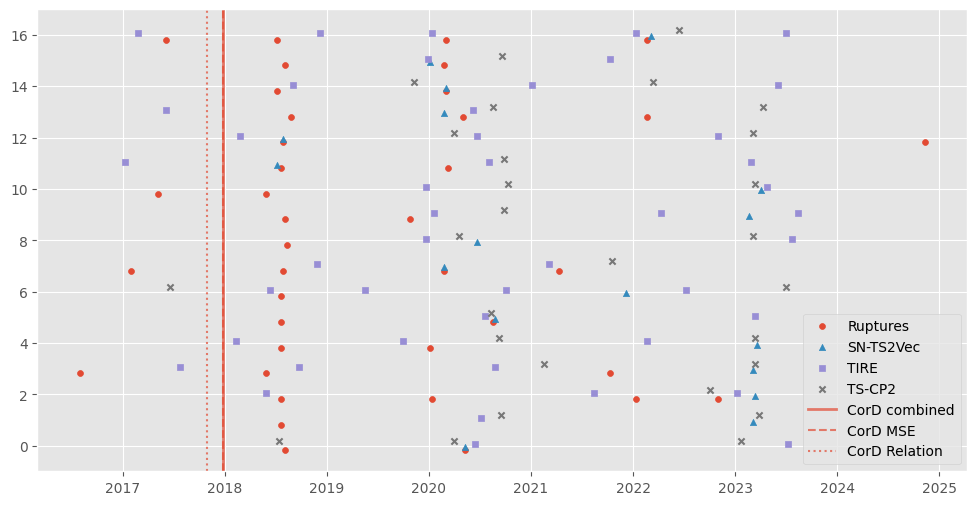

Change points for cluster 9: [337], MSE: [337], Relation: [42]
Cluster members: ['GOV_HLH_data.csv', 'GOV_LEG_data.csv', 'GOV_USA_data.csv', 'GOV_USAGOV_data.csv', 'LEG_GOV_data.csv', 'USA_PTY_data.csv', 'USA_USAGOV_data.csv', 'USAGOV_GOV_data.csv', 'USAGOV_USA_data.csv']
Cluster 9
TIRE: [np.float64(58.666666666666664)]
SN-TS2Vec: [np.float64(157.44444444444446)]
TS-CP2: [np.float64(58.666666666666664)]
Ruptures: [np.float64(50.0)]


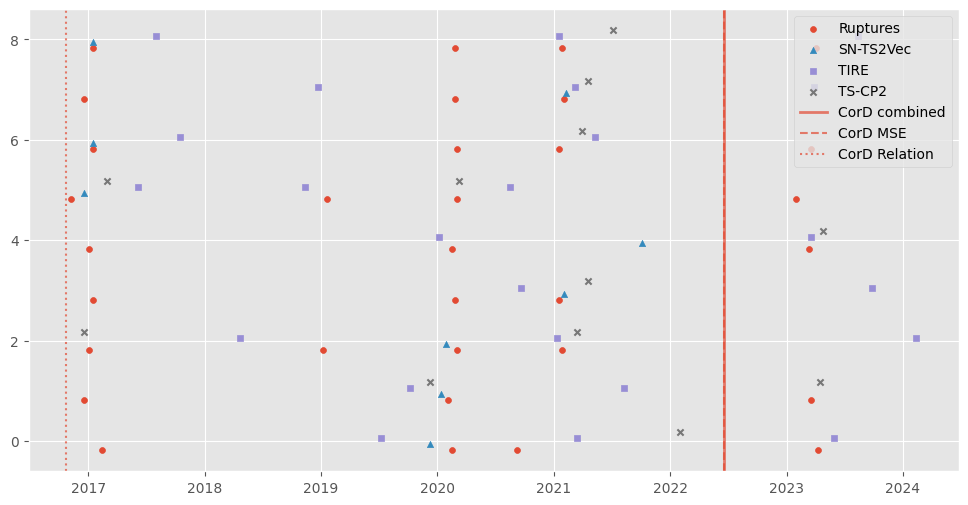

Change points for cluster 10: [402], MSE: [403], Relation: [441]
Cluster members: ['CAN_CVL_data.csv', 'GOV_ISR_data.csv', 'ISR_PSE_data.csv', 'ISRGOV_ISR_data.csv', 'PSE_ISR_data.csv', 'USA_ISR_data.csv']
Cluster 10
TIRE: [np.float64(20.5)]
SN-TS2Vec: [np.float64(5.833333333333333)]
TS-CP2: [np.float64(19.333333333333332)]
Ruptures: [np.float64(0.8333333333333334)]


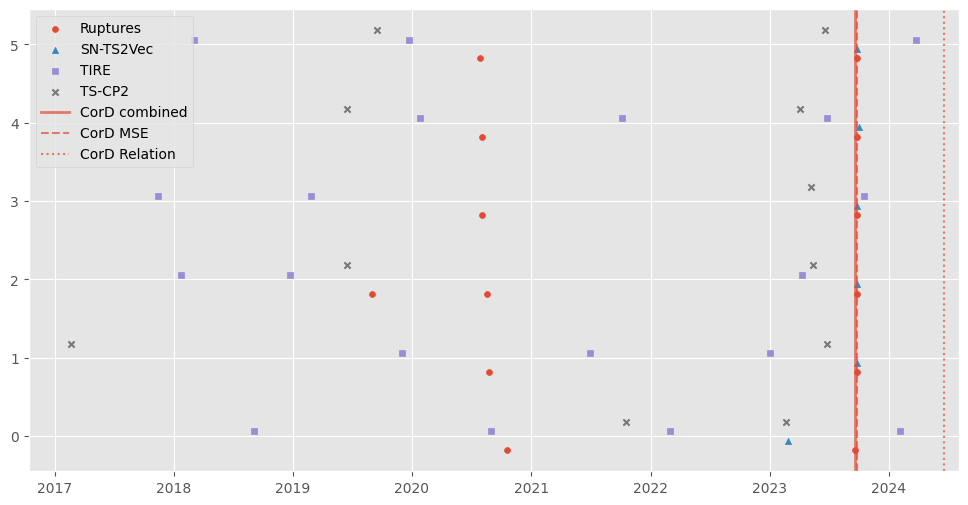

Change points for cluster 11: [29], MSE: [29], Relation: [55]
Cluster members: ['AFR_GOV_data.csv', 'AUS_USA_data.csv', 'BUS_AUS_data.csv', 'GOV_MED_data.csv', 'IND_GOV_data.csv']
Cluster 11
TIRE: [np.float64(102.8)]
SN-TS2Vec: [np.float64(289.4)]
TS-CP2: [np.float64(190.4)]
Ruptures: [np.float64(49.2)]


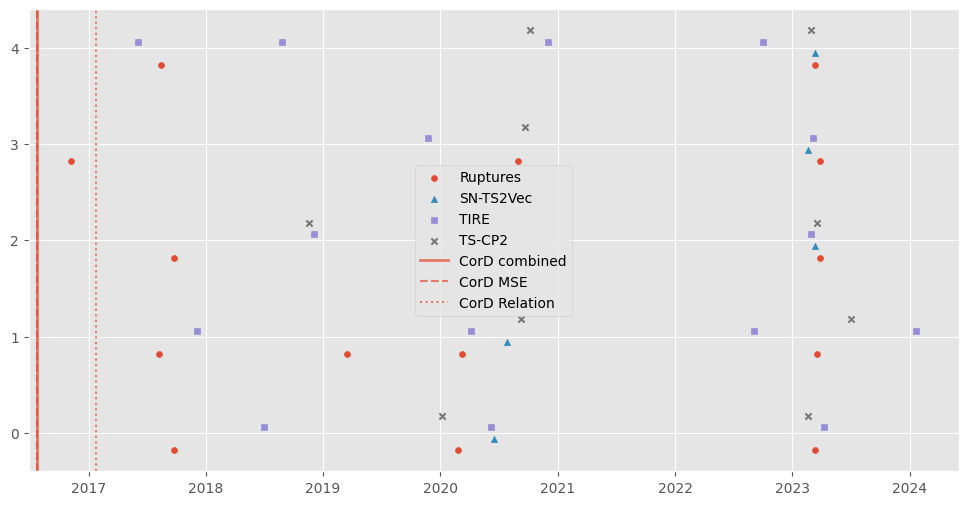

Change points for cluster 12: [68], MSE: [67], Relation: [363]
Cluster members: ['GOV_NGA_data.csv', 'JUD_CVL_data.csv', 'NGA_GOV_data.csv', 'NGAGOV_NGA_data.csv', 'USA_JUD_data.csv']
Cluster 12
TIRE: [np.float64(112.4)]
SN-TS2Vec: [np.float64(276.4)]
TS-CP2: [np.float64(207.2)]
Ruptures: [np.float64(60.6)]


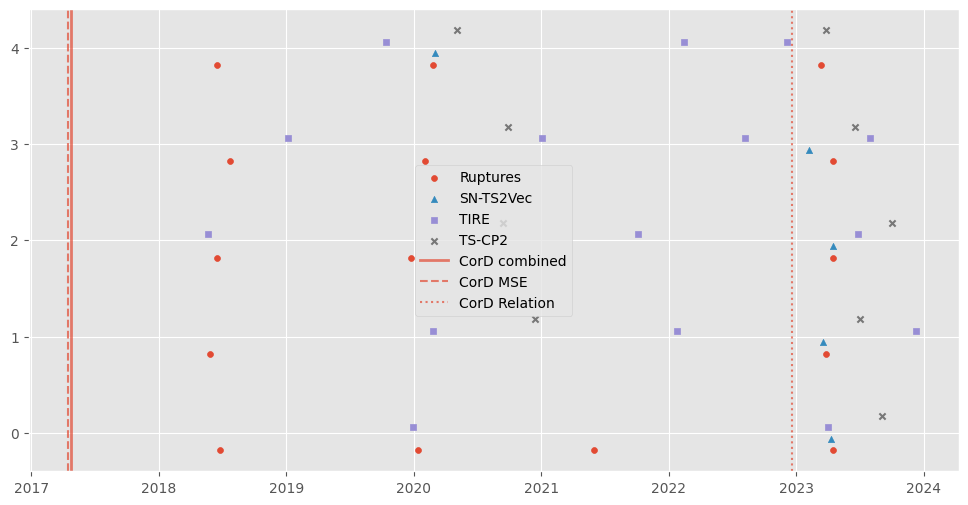

Change points for cluster 13: [44], MSE: [44], Relation: [153]
Cluster members: ['MED_USA_data.csv', 'USA_CVL_data.csv', 'USAMED_USA_data.csv']
Cluster 13
TIRE: [np.float64(99.66666666666667)]
SN-TS2Vec: [np.float64(161.33333333333334)]
TS-CP2: [np.float64(265.0)]
Ruptures: [np.float64(29.666666666666668)]


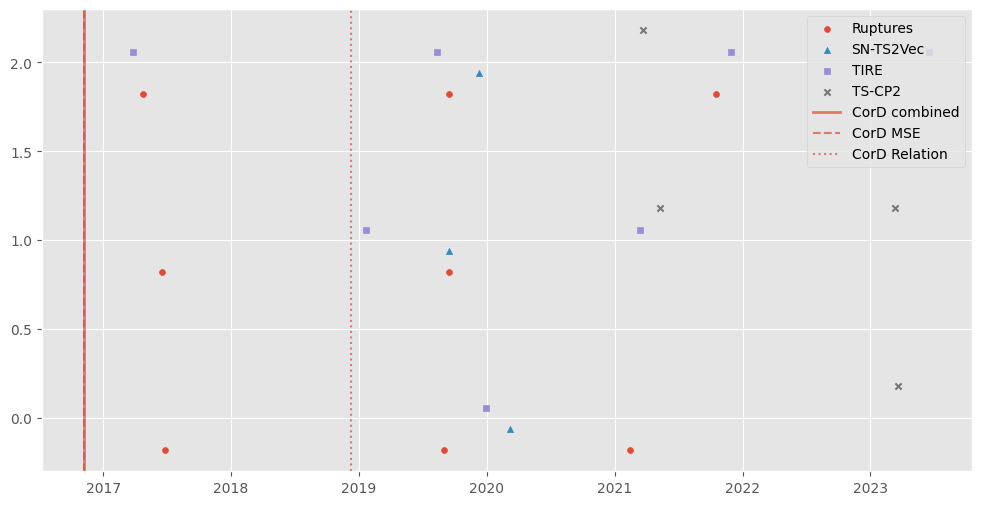

Results for cluster 14 not found.
Change points for cluster 15: [117], MSE: [117], Relation: [15]
Cluster members: ['AFR_ZAF_data.csv', 'CHN_BUS_data.csv', 'COP_GOV_data.csv', 'COP_USA_data.csv', 'GOV_IND_data.csv', 'LEG_CVL_data.csv', 'USA_AUS_data.csv', 'USA_CRM_data.csv', 'ZAF_AFR_data.csv']
Cluster 15
TIRE: [np.float64(58.77777777777778)]
SN-TS2Vec: [np.float64(210.0)]
TS-CP2: [np.float64(114.88888888888889)]
Ruptures: [np.float64(97.88888888888889)]


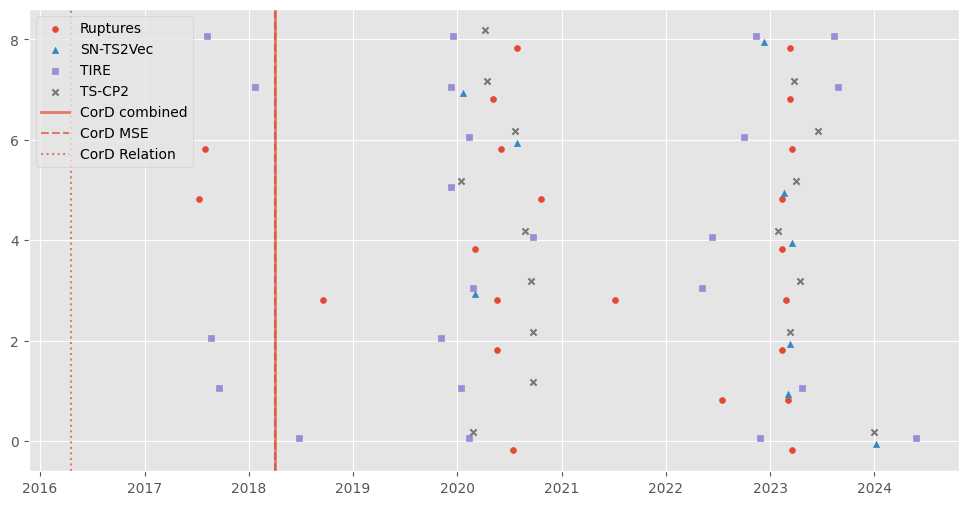

Change points for cluster 16: [63], MSE: [63], Relation: [177]
Cluster members: ['BUS_CAN_data.csv', 'EDU_USAEDU_data.csv', 'FRA_GBR_data.csv', 'GBR_FRA_data.csv', 'GBR_USA_data.csv', 'GBRGOV_GBR_data.csv', 'GOV_MIL_data.csv', 'OPP_COP_data.csv', 'USA_ELI_data.csv', 'USA_GBR_data.csv']
Cluster 16
TIRE: [np.float64(86.9)]
SN-TS2Vec: [np.float64(228.6)]
TS-CP2: [np.float64(212.2)]
Ruptures: [np.float64(106.2)]


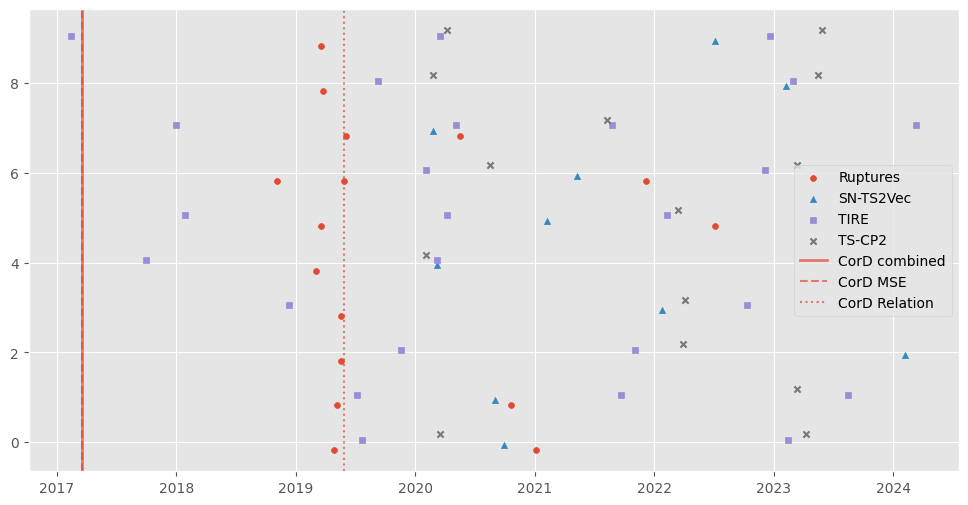

Results for cluster 17 not found.
Change points for cluster 18: [333], MSE: [334], Relation: [157]
Cluster members: ['COP_OPP_data.csv', 'LEG_USA_data.csv', 'USA_IRN_data.csv', 'USA_LEG_data.csv']
Cluster 18
TIRE: [np.float64(22.75)]
SN-TS2Vec: [np.float64(90.0)]
TS-CP2: [np.float64(87.0)]
Ruptures: [np.float64(85.25)]


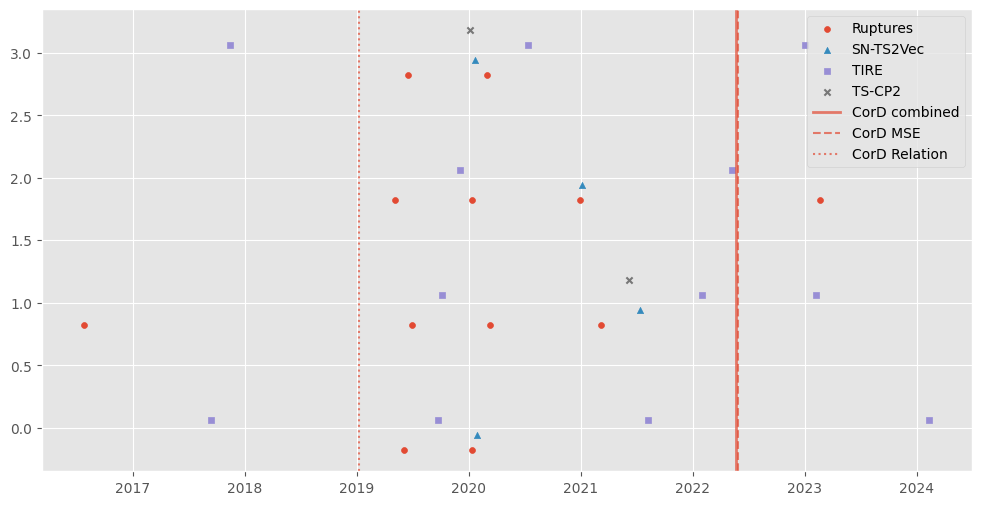

Change points for cluster 19: [293], MSE: [293], Relation: [82]
Cluster members: ['CVL_CAN_data.csv', 'CVL_GOV_data.csv', 'GBR_EDU_data.csv', 'GOV_CVL_data.csv', 'GOV_PAK_data.csv', 'PAK_GOV_data.csv', 'USA_USACVL_data.csv', 'USA_USAMED_data.csv']
Cluster 19
TIRE: [np.float64(59.625)]
SN-TS2Vec: [np.float64(68.375)]
TS-CP2: [np.float64(47.142857142857146)]
Ruptures: [np.float64(58.125)]


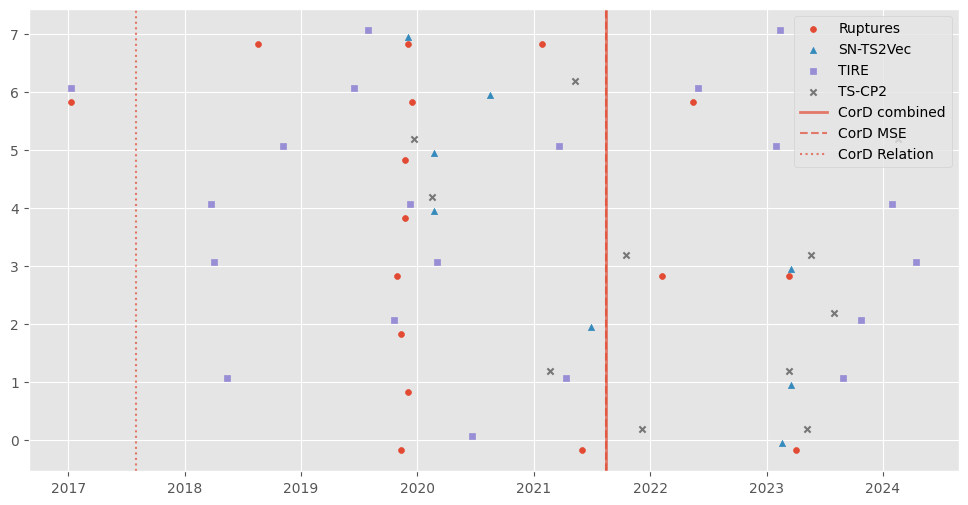

In [125]:
for i in range(np.max(cluster_labels)+1):
    try:
        results = np.load(f"C:/Users/cgl_0/OneDrive/Thesis/codes/results/cord_cpd/cluster_{i}.npy", allow_pickle=True).item()
    except FileNotFoundError:
        print(f"Results for cluster {i} not found.")
        continue
    print(f"Change points for cluster {i}: {results['pred_combined_cp']}, MSE: {results['pred_mse_cp']}, Relation: {results['pred_relation_cp']}")
    # get the indices of the data points belonging to the current cluster
    cluster_indices = np.where(cluster_labels == i)[0]

    print(f"Cluster members: {[file_names[j] for j in cluster_indices]}")

    tire_cluster = tire_cps[cluster_indices, :]
    snts_cluster = s_zeros[cluster_indices, :]
    tscp2_cluster = t_zeros[cluster_indices, :]
    rpt_cluster = rpt_cps[cluster_indices, :]

    cord_cps = np.asarray(results["pred_combined_cp"])

    dist_tire = cord_distance_to_model(cord_cps, tire_cluster)
    dist_snts = cord_distance_to_model(cord_cps, snts_cluster)
    dist_tscp2 = cord_distance_to_model(cord_cps, tscp2_cluster)
    dist_rpt = cord_distance_to_model(cord_cps, rpt_cluster)

    print(f"Cluster {i}")
    print("TIRE:", dist_tire)
    print("SN-TS2Vec:", dist_snts)
    print("TS-CP2:", dist_tscp2)
    print("Ruptures:", dist_rpt)

    fig, ax = plt.subplots(figsize=(12, 6))

    # -------------------------------------------------
    # Individual actor-pair changepoints
    # -------------------------------------------------

    row, cp = np.nonzero(rpt_cluster)
    ax.scatter(
        dates[cp],
        row - 0.18,
        marker="o",
        s=18,
        label="Ruptures"
    )

    row, cp = np.nonzero(snts_cluster)
    ax.scatter(
        dates[cp],
        row - 0.06,
        marker="^",
        s=20,
        label="SN-TS2Vec"
    )

    row, cp = np.nonzero(tire_cluster)
    ax.scatter(
        dates[cp],
        row + 0.06,
        marker="s",
        s=18,
        label="TIRE"
    )

    row, cp = np.nonzero(tscp2_cluster)
    ax.scatter(
        dates[cp],
        row + 0.18,
        marker="x",
        s=20,
        label="TS-CP2"
    )

    # -------------------------------------------------
    # CorD cluster-level changepoints
    # -------------------------------------------------

    for j, cp in enumerate(results["pred_combined_cp"]):
        ax.axvline(
            dates[int(cp)],
            linestyle="-",
            linewidth=2,
            alpha=0.7,
            label="CorD combined" if j == 0 else None
        )

    for j, cp in enumerate(results["pred_mse_cp"]):
        ax.axvline(
            dates[int(cp)],
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
            label="CorD MSE" if j == 0 else None
        )

    for j, cp in enumerate(results["pred_relation_cp"]):
        ax.axvline(
            dates[int(cp)],
            linestyle=":",
            linewidth=1.5,
            alpha=0.7,
            label="CorD Relation" if j == 0 else None
        )
    
    ax.legend()
    plt.show()

    

In [128]:
cluster_labels
# len of each cluster
for cluster_id in np.unique(cluster_labels):
    print(f"Cluster {cluster_id}: {np.sum(cluster_labels == cluster_id)}")

Cluster 0: 5
Cluster 1: 10
Cluster 2: 27
Cluster 3: 4
Cluster 4: 17
Cluster 5: 25
Cluster 6: 8
Cluster 7: 5
Cluster 8: 17
Cluster 9: 9
Cluster 10: 6
Cluster 11: 5
Cluster 12: 5
Cluster 13: 3
Cluster 14: 46
Cluster 15: 9
Cluster 16: 10
Cluster 17: 1
Cluster 18: 4
Cluster 19: 8
